# BÀI TẬP LỚN HỌC MÁY  
## Phát hiện gian lận giao dịch thương mại điện tử

### 1. Giới thiệu đề tài

Đề tài xây dựng mô hình **phân loại nhị phân** nhằm dự đoán một giao dịch thương mại điện tử có phải gian lận hay không.

Biến mục tiêu là `is_fraud`:

- `0`: giao dịch hợp lệ;
- `1`: giao dịch gian lận.

Mỗi giao dịch được mô tả bởi các nhóm thông tin như số tiền, hành vi giao dịch trước đây của người dùng, quốc gia giao dịch, quốc gia phát hành thẻ, kênh giao dịch, loại người bán, khoảng cách vận chuyển và kết quả của các cơ chế xác thực bảo mật.

Dữ liệu gian lận thường **mất cân bằng mạnh**, vì số giao dịch hợp lệ lớn hơn nhiều so với số giao dịch gian lận. Do đó, bài không lựa chọn mô hình chỉ dựa trên Accuracy mà ưu tiên:

- **Recall:** khả năng phát hiện các giao dịch gian lận thật;
- **F2-score:** ưu tiên Recall cao hơn Precision;
- **PR-AUC:** phù hợp khi lớp dương là lớp hiếm;
- **MCC:** đánh giá cân bằng cả bốn thành phần của confusion matrix;
- **Cost:** phạt trường hợp bỏ sót gian lận nặng hơn cảnh báo nhầm.

### Quy trình thực hiện

1. Đọc và kiểm tra dữ liệu.
2. Loại các cột không dùng, bao gồm `transaction_time`.
3. Kiểm tra missing value, duplicate và giá trị bất hợp lý.
4. Chuẩn hóa biến phân loại và gộp nhóm hiếm.
5. Feature Engineering rút gọn.
6. Xử lý missing, One-Hot Encoding và Scaling.
7. EDA sau tiền xử lý.
8. Chia Train, Validation và Test.
9. Huấn luyện các mô hình baseline và mô hình boosting.
10. Tối ưu LightGBM và XGBoost bằng Optuna.
11. Tuning threshold trên Validation.
12. Chọn champion model và đánh giá cuối trên Test.
13. Phân tích Feature Importance, dự đoán mẫu thật và lưu mô hình.


In [1]:
# ============================================================
# 0. CÀI ĐẶT THƯ VIỆN
# ============================================================

!pip -q install lightgbm xgboost optuna shap joblib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 9.4 MB/s eta 0:00:00


## 1.1. Cài đặt và khai báo thư viện

Cell đầu tiên cài đặt các thư viện chưa có sẵn trên Google Colab. Sau đó, notebook khai báo các thư viện phục vụ từng nhóm công việc:

- `pandas`, `numpy`: xử lý dữ liệu;
- `matplotlib`, `seaborn`: trực quan hóa;
- `scikit-learn`: chia dữ liệu, scaling, mô hình baseline và metric;
- `LightGBM`, `XGBoost`: mô hình boosting;
- `Optuna`: tối ưu siêu tham số;
- `joblib`: lưu mô hình sau huấn luyện.

`RANDOM_STATE = 42` được cố định để quá trình chia dữ liệu và huấn luyện có thể tái lập. Threshold được khảo sát trong khoảng từ `0.001` đến `0.999`, còn F2-score được chọn làm metric trọng tâm.


In [2]:
# ============================================================
# 1. IMPORT THƯ VIỆN VÀ CẤU HÌNH
# ============================================================

import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler, StandardScaler

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    fbeta_score,
    roc_auc_score,
    average_precision_score,
    matthews_corrcoef,
    confusion_matrix,
    classification_report,
    RocCurveDisplay,
    PrecisionRecallDisplay
)

import lightgbm as lgb
from lightgbm import LGBMClassifier

from xgboost import XGBClassifier

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

import joblib

RANDOM_STATE = 42
TARGET_COL = "is_fraud"

# Optuna trials
N_TRIALS_LGBM = 50
N_TRIALS_XGB = 50

# Threshold tuning chạy tự do gần như toàn miền
THRESHOLD_MIN = 0.001
THRESHOLD_MAX = 0.999
THRESHOLD_STEP = 0.002

# Metric chính để chọn threshold và champion
MAIN_METRIC = "F2"

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

sns.set_theme(style="whitegrid")

print("Cấu hình hoàn tất.")
print("Threshold range:", THRESHOLD_MIN, "->", THRESHOLD_MAX)
print("Main metric:", MAIN_METRIC)

Cấu hình hoàn tất.
Threshold range: 0.001 -> 0.999
Main metric: F2


## 2. Thu thập và đọc dữ liệu

Dữ liệu được đọc từ Google Drive bằng `pandas.read_csv()`. Sau khi tải dữ liệu, tên cột được chuẩn hóa theo ba bước:

1. Xóa khoảng trắng thừa ở đầu và cuối;
2. Chuyển toàn bộ về chữ thường;
3. Thay khoảng trắng bằng dấu gạch dưới.

Việc chuẩn hóa tên cột giúp tránh lỗi do cùng một cột nhưng được viết khác định dạng. Notebook đồng thời kiểm tra sự tồn tại của biến mục tiêu `is_fraud`, kích thước dữ liệu, danh sách cột, kiểu dữ liệu và một số dòng đầu tiên.


In [3]:
# ============================================================
# 2. LOAD DỮ LIỆU + CHUẨN HÓA TÊN CỘT
# ============================================================

from google.colab import drive
drive.mount("/content/drive")

DATA_PATH = "/content/drive/MyDrive/e-commerce_fraud_detection/transactions.csv"

df_raw = pd.read_csv(DATA_PATH)

# Chuẩn hóa tên cột để tránh lỗi do khoảng trắng, chữ hoa/thường
df_raw.columns = (
    df_raw.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_", regex=False)
)

print("Đọc dữ liệu thành công.")
print("Shape dữ liệu gốc:", df_raw.shape)
print("Danh sách cột sau chuẩn hóa:")
print(df_raw.columns.tolist())

if TARGET_COL not in df_raw.columns:
    raise ValueError(
        f"Không tìm thấy target '{TARGET_COL}'. "
        f"Các cột hiện có: {df_raw.columns.tolist()}"
    )

display(df_raw.head())
display(df_raw.info())

Mounted at /content/drive
Đọc dữ liệu thành công.
Shape dữ liệu gốc: (299695, 17)
Danh sách cột sau chuẩn hóa:
['transaction_id', 'user_id', 'account_age_days', 'total_transactions_user', 'avg_amount_user', 'amount', 'country', 'bin_country', 'channel', 'merchant_category', 'promo_used', 'avs_match', 'cvv_result', 'three_ds_flag', 'transaction_time', 'shipping_distance_km', 'is_fraud']


,transaction_id,user_id,account_age_days,total_transactions_user,avg_amount_user,amount,country,bin_country,channel,merchant_category,promo_used,avs_match,cvv_result,three_ds_flag,transaction_time,shipping_distance_km,is_fraud
0,1,1,141,47,147.93,84.75,FR,FR,web,travel,0,1,1,1,2024-01-06T04:09:39Z,370.95,0
1,2,1,141,47,147.93,107.90,FR,FR,web,travel,0,0,0,0,2024-01-09T20:13:47Z,149.62,0
2,3,1,141,47,147.93,92.36,FR,FR,app,travel,1,1,1,1,2024-01-12T06:20:11Z,164.08,0
3,4,1,141,47,147.93,112.47,FR,FR,web,fashion,0,1,1,1,2024-01-15T17:00:04Z,397.40,0
4,5,1,141,47,147.93,132.91,FR,US,web,electronics,0,1,1,1,2024-01-17T01:27:31Z,935.28,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299695 entries, 0 to 299694
Data columns (total 17 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   transaction_id           299695 non-null  int64  
 1   user_id                  299695 non-null  int64  
 2   account_age_days         299695 non-null  int64  
 3   total_transactions_user  299695 non-null  int64  
 4   avg_amount_user          299695 non-null  float64
 5   amount                   299695 non-null  float64
 6   country                  299695 non-null  object 
 7   bin_country              299695 non-null  object 
 8   channel                  299695 non-null  object 
 9   merchant_category        299695 non-null  object 
 10  promo_used               299695 non-null  int64  
 11  avs_match                299695 non-null  int64  
 12  cvv_result               299695 non-null  int64  
 13  three_ds_flag            299695 non-null  int64  
 14  tran

None

# 3. Tiền xử lý dữ liệu
Tiền xử lý dữ liệu là bước làm sạch, chuẩn hóa và biến đổi dữ liệu trước khi thực hiện khai phá dữ liệu và huấn luyện mô hình. Mục tiêu của bước này là hạn chế lỗi dữ liệu, giảm nhiễu, giảm số lượng đặc trưng không cần thiết và đưa dữ liệu về định dạng phù hợp với các thuật toán học máy.

Trong bài toán phát hiện gian lận, việc tiền xử lý cần được thực hiện cẩn thận vì những giá trị bất thường hoặc hiếm chưa chắc là dữ liệu sai. Trong nhiều trường hợp, chúng có thể chính là dấu hiệu giúp nhận biết giao dịch gian lận.

## 3.1. Loại bỏ các cột không sử dụng

Ba cột được loại khỏi dữ liệu mô hình:

- `transaction_id`: chỉ là mã định danh giao dịch;
- `user_id`: chỉ là mã định danh người dùng;
- `transaction_time`: được loại để bài toán không sử dụng đặc trưng thời gian.

Các cột định danh thường không biểu diễn bản chất của hành vi gian lận và có thể khiến mô hình ghi nhớ từng đối tượng. Sau khi loại cột, `is_fraud` được ép về kiểu số nguyên để thống nhất nhãn phân loại.

Bài toán sau bước này là **tabular binary classification - Phân loại nhị phân trên dữ liệu bảng**, không phải dự báo chuỗi thời gian như ARIMA, Prophet hoặc LSTM.


In [4]:
# ============================================================
# 3.1. BỎ CỘT KHÔNG DÙNG
# ============================================================

df = df_raw.copy()

drop_cols = [
    "transaction_id",
    "user_id",
    "transaction_time"
]

drop_cols = [col for col in drop_cols if col in df.columns]

df = df.drop(columns=drop_cols)

df[TARGET_COL] = df[TARGET_COL].astype(int)

print("Các cột đã bỏ:", drop_cols)
print("Shape sau khi bỏ cột:", df.shape)
display(df.head())

Các cột đã bỏ: ['transaction_id', 'user_id', 'transaction_time']
Shape sau khi bỏ cột: (299695, 14)


,account_age_days,total_transactions_user,avg_amount_user,amount,country,bin_country,channel,merchant_category,promo_used,avs_match,cvv_result,three_ds_flag,shipping_distance_km,is_fraud
0,141,47,147.93,84.75,FR,FR,web,travel,0,1,1,1,370.95,0
1,141,47,147.93,107.90,FR,FR,web,travel,0,0,0,0,149.62,0
2,141,47,147.93,92.36,FR,FR,app,travel,1,1,1,1,164.08,0
3,141,47,147.93,112.47,FR,FR,web,fashion,0,1,1,1,397.40,0
4,141,47,147.93,132.91,FR,US,web,electronics,0,1,1,1,935.28,0


## 3.2. Kiểm tra missing value và kiểu dữ liệu

Notebook kiểm tra hai dạng thiếu dữ liệu:

- Missing thực sự: `NaN`, `None`;
- Missing dạng chuỗi: chuỗi rỗng, `NA`, `N/A`, `null`, `Unknown`, `-`, `?`, v.v.

Bảng kết quả gồm kiểu dữ liệu, số lượng missing, tỷ lệ missing, số giá trị duy nhất và số giá trị có hình thức giống missing. Mục tiêu là phát hiện cả những trường hợp dữ liệu thiếu nhưng được lưu sai định dạng.

Kết quả của cell này được dùng để quyết định cách điền missing ở bước sau:

- Biến số: điền bằng median;
- Biến phân loại: điền bằng nhãn `Unknown`.


In [5]:
# ============================================================
# 3.2. KIỂM TRA MISSING, KIỂU DỮ LIỆU
# ============================================================
# Lưu shape ban đầu để so sánh
original_shape = df.shape

print("Shape ban đầu:", original_shape)

# ------------------------------------------------------------
# 1. KIỂM TRA MISSING VALUE THỰC SỰ
# ------------------------------------------------------------

missing_count = df.isnull().sum()
missing_rate = df.isnull().mean() * 100

# ------------------------------------------------------------
# 2. KIỂM TRA CÁC GIÁ TRỊ CÓ THỂ ĐƯỢC XEM LÀ MISSING
#    Ví dụ: "", " ", "?", "NA", "N/A", "null", "-", ...
# ------------------------------------------------------------

missing_like_values = [
    "", " ", "?", "??",
    "NA", "N/A", "na", "n/a",
    "NULL", "null",
    "None", "none",
    "-", "--",
    "Unknown", "unknown"
]

missing_like_count = {}

for col in df.columns:
    if df[col].dtype == "object":
        missing_like_count[col] = (
            df[col]
            .astype(str)
            .str.strip()
            .isin(missing_like_values)
            .sum()
        )
    else:
        missing_like_count[col] = 0

missing_like_count = pd.Series(missing_like_count)

# ------------------------------------------------------------
# 3. TỔNG HỢP BẢNG KIỂM TRA MISSING
# ------------------------------------------------------------

missing_df = pd.DataFrame({
    "Column": df.columns,
    "Dtype": df.dtypes.astype(str).values,
    "Missing_Count": missing_count.values,
    "Missing_Rate_%": missing_rate.values,
    "Missing_Like_Count": missing_like_count.values,
    "N_Unique": df.nunique(dropna=True).values
})

missing_df["Total_Missing_Check"] = (
    missing_df["Missing_Count"] + missing_df["Missing_Like_Count"]
)

missing_df = missing_df.sort_values(
    ["Total_Missing_Check", "Missing_Rate_%"],
    ascending=False
)

display(missing_df)

# ------------------------------------------------------------
# 4. IN NHẬN XÉT NHANH VỀ MISSING
# ------------------------------------------------------------

total_missing = missing_df["Missing_Count"].sum()
total_missing_like = missing_df["Missing_Like_Count"].sum()

print("Tổng số missing thật sự:", total_missing)
print("Tổng số giá trị dạng missing-like:", total_missing_like)

if total_missing == 0 and total_missing_like == 0:
    print("Kết luận: Dữ liệu không có missing value rõ ràng.")
else:
    print("Kết luận: Dữ liệu có missing hoặc giá trị dạng missing-like, cần xử lý trước khi train mô hình.")


# ------------------------------------------------------------
# 5. SO SÁNH SHAPE TRƯỚC VÀ SAU
# ------------------------------------------------------------

print("\nShape trước xử lý:", original_shape)
print("Shape sau xử lý:", df.shape)
print("Số dòng đã giảm:", original_shape[0] - df.shape[0])

Shape ban đầu: (299695, 14)


,Column,Dtype,Missing_Count,Missing_Rate_%,Missing_Like_Count,N_Unique,Total_Missing_Check
0,account_age_days,int64,0,0.0,0,1801,0
1,total_transactions_user,int64,0,0.0,0,21,0
2,avg_amount_user,float64,0,0.0,0,5347,0
3,amount,float64,0,0.0,0,60043,0
4,country,object,0,0.0,0,10,0
5,bin_country,object,0,0.0,0,10,0
6,channel,object,0,0.0,0,2,0
7,merchant_category,object,0,0.0,0,5,0
8,promo_used,int64,0,0.0,0,2,0
9,avs_match,int64,0,0.0,0,2,0


Tổng số missing thật sự: 0
Tổng số giá trị dạng missing-like: 0
Kết luận: Dữ liệu không có missing value rõ ràng.

Shape trước xử lý: (299695, 14)
Shape sau xử lý: (299695, 14)
Số dòng đã giảm: 0


## 3.3. Kiểm tra duplicate

Duplicate được kiểm tra theo nhiều mức:

1. **Trùng toàn bộ dòng:** tất cả các cột giống nhau;
2. **Trùng sau chuẩn hóa chuỗi:** phát hiện khác biệt do chữ hoa, chữ thường hoặc khoảng trắng;
3. **Trùng toàn bộ feature nhưng không xét target:** kiểm tra các mẫu đầu vào giống nhau;
4. **Feature giống nhau nhưng target khác nhau:** phát hiện dữ liệu có thể gây nhiễu nhãn;
5. **Tần suất xuất hiện của từng nhóm duplicate.**

Chỉ duplicate toàn dòng mới được tự động loại bỏ. Các mẫu có feature giống nhau nhưng nhãn khác nhau cần được xem là xung đột dữ liệu thay vì xóa tùy ý.


In [6]:
# ============================================================
# KIỂM TRA DUPLICATE CHUYÊN SÂU
# ============================================================

print("=" * 80)
print("KIỂM TRA DUPLICATE CHUYÊN SÂU")
print("=" * 80)

original_shape = df.shape
print("Shape ban đầu:", original_shape)

# ------------------------------------------------------------
# 1. DUPLICATE TOÀN DÒNG
# ------------------------------------------------------------

full_duplicate_count = df.duplicated().sum()
full_duplicate_rate = full_duplicate_count / len(df) * 100

print("\n1. Duplicate toàn dòng")
print("Số dòng trùng lặp hoàn toàn:", full_duplicate_count)
print("Tỷ lệ duplicate toàn dòng (%):", round(full_duplicate_rate, 4))

if full_duplicate_count > 0:
    print("\nCác dòng bị trùng hoàn toàn:")
    duplicate_full_df = df[df.duplicated(keep=False)].copy()
    display(duplicate_full_df.sort_values(by=list(df.columns)).head(20))
else:
    print("Không có duplicate toàn dòng.")


# ------------------------------------------------------------
# 2. DUPLICATE SAU KHI CHUẨN HÓA CHUỖI
#    Tránh lỗi do khoảng trắng hoặc chữ hoa/chữ thường
# ------------------------------------------------------------

df_check = df.copy()

object_cols = df_check.select_dtypes(include="object").columns

for col in object_cols:
    df_check[col] = (
        df_check[col]
        .astype(str)
        .str.strip()
        .str.lower()
    )

normalized_duplicate_count = df_check.duplicated().sum()
normalized_duplicate_rate = normalized_duplicate_count / len(df_check) * 100

print("\n2. Duplicate sau khi chuẩn hóa chuỗi")
print("Số dòng trùng sau chuẩn hóa:", normalized_duplicate_count)
print("Tỷ lệ duplicate sau chuẩn hóa (%):", round(normalized_duplicate_rate, 4))

if normalized_duplicate_count > full_duplicate_count:
    print("Có khả năng tồn tại duplicate do khác khoảng trắng hoặc chữ hoa/chữ thường.")

    normalized_dup_index = df_check[df_check.duplicated(keep=False)].index

    print("\nCác dòng nghi ngờ duplicate sau chuẩn hóa:")
    display(df.loc[normalized_dup_index].head(20))
else:
    print("Không phát hiện thêm duplicate do lỗi định dạng chuỗi.")


# ------------------------------------------------------------
# 3. DUPLICATE THEO FEATURE, KHÔNG TÍNH TARGET
#    Dùng để kiểm tra các mẫu đầu vào giống nhau
# ------------------------------------------------------------

feature_cols = [col for col in df.columns if col != TARGET_COL]

feature_duplicate_count = df.duplicated(subset=feature_cols).sum()
feature_duplicate_rate = feature_duplicate_count / len(df) * 100

print("\n3. Duplicate theo feature, không tính target")
print("Số dòng có feature trùng nhau:", feature_duplicate_count)
print("Tỷ lệ feature duplicate (%):", round(feature_duplicate_rate, 4))

if feature_duplicate_count > 0:
    feature_dup_df = df[df.duplicated(subset=feature_cols, keep=False)].copy()

    print("\nCác dòng có feature giống nhau:")
    display(feature_dup_df.sort_values(by=feature_cols).head(20))
else:
    print("Không có dòng nào trùng toàn bộ feature.")


# ------------------------------------------------------------
# 4. KIỂM TRA FEATURE GIỐNG NHAU NHƯNG TARGET KHÁC NHAU
#    Đây là trường hợp nguy hiểm hơn duplicate thông thường
# ------------------------------------------------------------

if feature_duplicate_count > 0:
    target_conflict = (
        df.groupby(feature_cols)[TARGET_COL]
        .nunique()
        .reset_index(name="Target_N_Unique")
    )

    conflict_features = target_conflict[target_conflict["Target_N_Unique"] > 1]

    print("\n4. Kiểm tra feature giống nhau nhưng target khác nhau")
    print("Số nhóm feature giống nhau nhưng target khác nhau:", len(conflict_features))

    if len(conflict_features) > 0:
        print("Cảnh báo: Có dữ liệu cùng đặc trưng đầu vào nhưng nhãn/giá trị target khác nhau.")
        print("Trường hợp này cần kiểm tra kỹ vì có thể làm mô hình học nhiễu.")

        conflict_detail = df.merge(
            conflict_features[feature_cols],
            on=feature_cols,
            how="inner"
        )

        display(conflict_detail.sort_values(by=feature_cols).head(20))
    else:
        print("Không có trường hợp feature giống nhau nhưng target khác nhau.")
else:
    print("\n4. Bỏ qua kiểm tra target conflict vì không có feature duplicate.")


# ------------------------------------------------------------
# 5. THỐNG KÊ SỐ LẦN XUẤT HIỆN CỦA CÁC DÒNG TRÙNG
# ------------------------------------------------------------

print("\n5. Thống kê nhóm duplicate toàn dòng")

duplicate_group_summary = (
    df.value_counts()
    .reset_index(name="Duplicate_Frequency")
)

duplicate_group_summary = duplicate_group_summary[
    duplicate_group_summary["Duplicate_Frequency"] > 1
]

if len(duplicate_group_summary) > 0:
    print("Các nhóm dòng xuất hiện nhiều hơn 1 lần:")
    display(duplicate_group_summary.head(20))
else:
    print("Không có nhóm dòng nào xuất hiện nhiều hơn 1 lần.")


# ------------------------------------------------------------
# 6. XỬ LÝ DUPLICATE
# ------------------------------------------------------------

print("\n6. Hướng xử lý duplicate")

if full_duplicate_count > 0:
    print("Có duplicate toàn dòng -> có thể xóa vì đây thường là dữ liệu bị lặp.")

    df = df.drop_duplicates().reset_index(drop=True)

    print("Đã xóa duplicate toàn dòng.")
    print("Shape sau khi xóa duplicate:", df.shape)
else:
    print("Không cần xóa duplicate toàn dòng.")

print("\nShape trước xử lý:", original_shape)
print("Shape sau xử lý:", df.shape)
print("Số dòng đã giảm:", original_shape[0] - df.shape[0])

KIỂM TRA DUPLICATE CHUYÊN SÂU
Shape ban đầu: (299695, 14)

1. Duplicate toàn dòng
Số dòng trùng lặp hoàn toàn: 0
Tỷ lệ duplicate toàn dòng (%): 0.0
Không có duplicate toàn dòng.

2. Duplicate sau khi chuẩn hóa chuỗi
Số dòng trùng sau chuẩn hóa: 0
Tỷ lệ duplicate sau chuẩn hóa (%): 0.0
Không phát hiện thêm duplicate do lỗi định dạng chuỗi.

3. Duplicate theo feature, không tính target
Số dòng có feature trùng nhau: 0
Tỷ lệ feature duplicate (%): 0.0
Không có dòng nào trùng toàn bộ feature.

4. Bỏ qua kiểm tra target conflict vì không có feature duplicate.

5. Thống kê nhóm duplicate toàn dòng
Không có nhóm dòng nào xuất hiện nhiều hơn 1 lần.

6. Hướng xử lý duplicate
Không cần xóa duplicate toàn dòng.

Shape trước xử lý: (299695, 14)
Shape sau xử lý: (299695, 14)
Số dòng đã giảm: 0


## 3.4. Kiểm tra giá trị bất hợp lý về mặt nghiệp vụ

Các biến như `amount`, `avg_amount_user`, `shipping_distance_km`, `account_age_days` và `total_transactions_user` không nên nhận giá trị âm.

Nếu phát hiện giá trị âm, notebook không xóa cả dòng mà chuyển giá trị đó thành `NaN`. Ở bước xử lý missing, các giá trị này được thay bằng median của biến tương ứng. Cách làm này giữ lại phần thông tin còn hợp lệ của bản ghi.


In [7]:
# ============================================================
# 3.2.1. KIỂM TRA VÀ XỬ LÝ GIÁ TRỊ BẤT THƯỜNG VỀ MẶT LOGIC
# ============================================================

logic_check_cols = [
    "amount",
    "avg_amount_user",
    "shipping_distance_km",
    "account_age_days",
    "total_transactions_user"
]

logic_check_cols = [
    col for col in logic_check_cols
    if col in df.columns
]

logic_report = []

for col in logic_check_cols:
    invalid_negative_count = (df[col] < 0).sum()
    invalid_rate = invalid_negative_count / len(df) * 100

    logic_report.append({
        "Column": col,
        "Invalid_Negative_Count": invalid_negative_count,
        "Invalid_Rate_%": invalid_rate
    })

logic_report_df = pd.DataFrame(logic_report)
display(logic_report_df)

# Các giá trị âm về mặt nghiệp vụ là không hợp lý.
# Đưa về NaN, sau đó xử lý missing ở bước sau.
for col in logic_check_cols:
    df.loc[df[col] < 0, col] = np.nan

print("Đã đưa các giá trị âm không hợp lý về NaN.")

,Column,Invalid_Negative_Count,Invalid_Rate_%
0,amount,0,0.0
1,avg_amount_user,0,0.0
2,shipping_distance_km,0,0.0
3,account_age_days,0,0.0
4,total_transactions_user,0,0.0


Đã đưa các giá trị âm không hợp lý về NaN.


## 3.5. Chuẩn hóa biến phân loại

Các biến dạng `object` hoặc `category` được:

- loại khoảng trắng ở đầu và cuối;
- chuyển về chữ thường;
- quy đổi các chuỗi biểu diễn missing thành `pd.NA`.

Ví dụ, `"US"`, `" us "` và `"Us"` sẽ được đưa về cùng một nhóm `"us"`. Điều này tránh tạo ra nhiều cột One-Hot khác nhau chỉ vì lỗi định dạng.

Việc chuẩn hóa giúp:
* giảm số lượng nhóm không cần thiết;
* giảm số cột sau One-Hot Encoding;
* hạn chế nhiễu dữ liệu;
* giúp mô hình học ổn định hơn.

In [8]:
# ============================================================
# 3.2.2. CHUẨN HÓA CATEGORICAL FEATURES
# ============================================================

cat_cols_raw = df.select_dtypes(include=["object", "category"]).columns.tolist()

print("Categorical columns trước chuẩn hóa:")
print(cat_cols_raw)

for col in cat_cols_raw:
    df[col] = (
        df[col]
        .astype("string")
        .str.strip()
        .str.lower()
    )

    # Chuẩn hóa các chuỗi rỗng hoặc biểu diễn thiếu dữ liệu
    df[col] = df[col].replace(
        {
            "": pd.NA,
            "nan": pd.NA,
            "none": pd.NA,
            "null": pd.NA,
            "na": pd.NA,
            "n/a": pd.NA
        }
    )

print("Đã chuẩn hóa categorical features: strip + lower + xử lý chuỗi rỗng.")

if len(cat_cols_raw) > 0:
    display(df[cat_cols_raw].head())
else:
    display(pd.DataFrame())

Categorical columns trước chuẩn hóa:
['country', 'bin_country', 'channel', 'merchant_category']
Đã chuẩn hóa categorical features: strip + lower + xử lý chuỗi rỗng.


,country,bin_country,channel,merchant_category
0,fr,fr,web,travel
1,fr,fr,web,travel
2,fr,fr,app,travel
3,fr,fr,web,fashion
4,fr,us,web,electronics


## 3.6. Gộp nhóm phân loại hiếm

Những nhóm xuất hiện dưới `0.5%` số quan sát được gộp thành nhóm `other`.

Mục đích:

- giảm số lượng cột sau One-Hot Encoding;
- hạn chế mô hình học các nhóm quá ít mẫu;
- giảm nhiễu và thời gian huấn luyện;
- cải thiện khả năng tổng quát hóa trên dữ liệu mới;
- giảm nguy cơ overfitting.

Bảng kết quả cho biết số nhóm ban đầu, số nhóm hiếm và một số nhãn hiếm tiêu biểu của từng cột.

Tuy nhiên, một nhóm hiếm vẫn có thể chứa tỷ lệ gian lận cao. Vì vậy, bài vẫn sẽ tiếp tục kiểm tra số lượng giao dịch, fraud rate và fraud lift của từng nhóm trong phần EDA


In [9]:
# ============================================================
# 3.2.3. GỘP NHÓM HIẾM TRONG CATEGORICAL FEATURES
# ============================================================

def group_rare_categories(df_input, cat_cols, min_freq=0.005):
    """
    Gộp các nhóm categorical xuất hiện quá ít thành 'other'.
    min_freq=0.005 nghĩa là nhóm xuất hiện dưới 0.5% sẽ được gộp.
    """
    df_out = df_input.copy()
    rare_summary = []

    for col in cat_cols:
        freq = df_out[col].value_counts(normalize=True, dropna=True)
        rare_labels = freq[freq < min_freq].index.tolist()

        rare_summary.append({
            "Column": col,
            "Num_Unique_Before": df_input[col].nunique(dropna=True),
            "Num_Rare_Groups": len(rare_labels),
            "Rare_Groups_Example": rare_labels[:10]
        })

        df_out[col] = df_out[col].replace(rare_labels, "other")

    return df_out, pd.DataFrame(rare_summary)


df, rare_summary_df = group_rare_categories(
    df_input=df,
    cat_cols=cat_cols_raw,
    min_freq=0.005
)

display(rare_summary_df)
print("Đã gộp nhóm hiếm thành 'other'.")

,Column,Num_Unique_Before,Num_Rare_Groups,Rare_Groups_Example
0,country,10,0,[]
1,bin_country,10,0,[]
2,channel,2,0,[]
3,merchant_category,5,0,[]


Đã gộp nhóm hiếm thành 'other'.


## 3.7. Kiểm tra độ lệch phân phối

Skewness được dùng để đo mức độ bất đối xứng của phân phối:

- Skewness gần `0`: phân phối tương đối cân đối;
- Skewness dương lớn: lệch phải;
- Skewness âm lớn về trị tuyệt đối: lệch trái.

Các biến tài chính và khoảng cách thường lệch phải vì phần lớn giao dịch có giá trị nhỏ hoặc trung bình, trong khi một số ít giao dịch có giá trị rất lớn. Kết quả kiểm tra skewness được sử dụng làm cơ sở để tạo biến log ở bước Feature Engineering.


,Column,Skewness
3,amount,8.298999
2,avg_amount_user,6.486788
8,shipping_distance_km,3.499537
4,promo_used,1.921017
0,account_age_days,-0.022311
1,total_transactions_user,-0.127329
7,three_ds_flag,-1.384498
5,avs_match,-1.834704
6,cvv_result,-2.228433


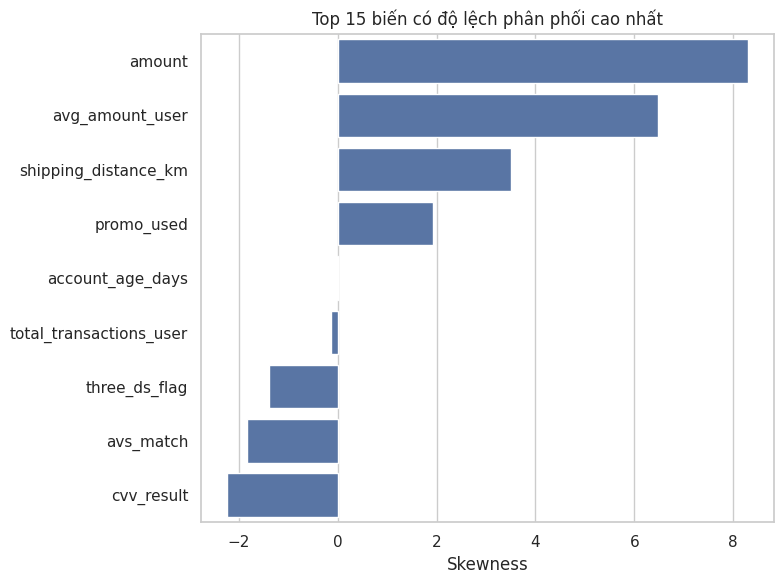

In [10]:
# ============================================================
# 3.2.4. KIỂM TRA SKEWNESS TRƯỚC LOG-TRANSFORM
# ============================================================

numeric_cols_for_skew = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols_for_skew = [
    col for col in numeric_cols_for_skew
    if col != TARGET_COL
]

skewness_df = pd.DataFrame({
    "Column": numeric_cols_for_skew,
    "Skewness": [df[col].skew() for col in numeric_cols_for_skew]
}).sort_values("Skewness", ascending=False)

display(skewness_df)

plt.figure(figsize=(8, 6))
sns.barplot(
    data=skewness_df.head(15),
    x="Skewness",
    y="Column"
)
plt.title("Top 15 biến có độ lệch phân phối cao nhất")
plt.xlabel("Skewness")
plt.ylabel("")
plt.tight_layout()
plt.show()

## 3.8. Feature Engineering rút gọn

Feature Engineering là bước tạo ra các bước đặc trưng mới từ các biến ban đầu nhằm giúp mô hình nhận biết rõ ràng hơn những hành vi bất thường.

Feature Engineering được rút gọn để chỉ giữ những biến mới có ý nghĩa nghiệp vụ rõ ràng. Việc giảm số lượng biến giúp:

- giảm số chiều sau mã hóa;
- giảm thời gian huấn luyện và Optuna;
- hạn chế feature trùng lặp;
- giảm nguy cơ overfitting;
- giúp Feature Importance dễ giải thích hơn.

### Các feature mới được giữ

| Feature | Cách tạo | Ý nghĩa |
|---|---|---|
| `log_amount` | `log(1 + amount)` | Giảm lệch phải của số tiền |
| `log_shipping_distance_km` | `log(1 + distance)` | Giảm ảnh hưởng của khoảng cách quá lớn |
| `country_mismatch` | `country != bin_country` | Quốc gia giao dịch khác quốc gia thẻ |
| `security_score` | Tổng AVS, CVV và 3DS thành công | Mức độ bảo mật tổng hợp |
| `security_fail_count` | Số kiểm tra bảo mật thất bại | Mức độ rủi ro bảo mật |
| `security_strong` | Cả ba cơ chế đều thành công | Giao dịch có xác thực mạnh |
| `amount_5x_avg` | `amount >= 5 × avg_amount_user` | Giao dịch lớn bất thường so với thói quen |
| `is_new_account_90d` | Tuổi tài khoản không quá 90 ngày | Đánh dấu tài khoản mới |
| `shipping_gt_500km` | Khoảng cách từ 500 km | Đánh dấu vận chuyển xa |

Phép log-transform được tính theo:

$$
x_{\log}=\ln(1+x)
$$

Chỉ một ngưỡng mạnh được giữ cho mỗi nhóm đặc trưng. Các ngưỡng 2 lần, 3 lần, 10 lần; nhiều mốc tuổi tài khoản; nhiều mốc khoảng cách và các interaction feature thủ công được loại bỏ vì trùng ý nghĩa hoặc có đóng góp thấp.

## 3.8.1. Biến log_amount

Biến được tính theo công thức:
$$
\ln(1+\text{amount})
$$

Phép biến đổi log1p giúp nén các giá trị giao dịch quá lớn và giảm độ lệch phải của biến amount.
`log_amount` đặc biệt hữu ích đối với Logistic Regression vì mô hình tuyến tính nhạy với sự khác biệt lớn về độ lớn giữa các quan sát.

##3.8.2. Biến log_shipping_distance_km

Biến được tính theo công thức:
$$
\ln(1+\text{shipping_distance_km})
$$

Biến này giúp giảm ảnh hưởng của một số giao dịch có khoảng cách vận chuyển quá lớn.

Khoảng cách vận chuyển xa vẫn được giữ lại như một tín hiệu bất thường, nhưng không còn chi phối toàn bộ phân phối.

##3.8.3. Biến country_mismatch

Biến được xác định bằng:
$$
\begin{cases}
1, & \text{country}\neq\text{bin_country}\
0, & \text{country}=\text{bin_country}
\end{cases}
$$

Trong đó:

- `country`: quốc gia phát sinh giao dịch;
- `bin_country`: quốc gia phát hành thẻ.

Nếu hai quốc gia khác nhau, giao dịch có thể mang mức độ rủi ro cao hơn.

Biến này giúp mô hình nhận biết trực tiếp dấu hiệu bất thường về vị trí địa lý.

## 3.8.4. Biến security_score

Biến được tính bằng:
$$
\text{avs_match}
+
\text{cvv_result}
+
\text{three_ds_flag}
$$

Giá trị của security_score nằm trong khoảng từ 0 đến 3.

Biến này tổng hợp mức độ an toàn của giao dịch từ ba cơ chế bảo mật.

##3.8.5. Biến security_fail_count

Biến được tính bằng:
$$
3-\text{security_score}
$$

Biến này biểu diễn số kiểm tra bảo mật không thành công.

Giá trị càng lớn cho thấy giao dịch càng thất bại nhiều bước xác thực.

Do được suy ra trực tiếp từ `security_score`, hai biến này có tương quan nghịch rất mạnh. Việc giữ biến này chủ yếu giúp việc diễn giải theo hướng số lần thất bại trở nên trực quan hơn.

##3.8.6. Biến security_strong

Biến được xác định như sau:
$$
\begin{cases}
1, & \text{security_score}=3\
0, & \text{các trường hợp khác}
\end{cases}
$$

Biến này đánh dấu các giao dịch vượt qua đầy đủ cả ba cơ chế xác thực bảo mật.

##3.8.7. Biến amount_5x_avg

Biến được xác định bằng:
$$
\begin{cases}
1, & \text{amount}\geq 5\times\text{avg_amount_user}\
0, & \text{các trường hợp khác}
\end{cases}
$$

Biến này cho biết số tiền giao dịch hiện tại có lớn hơn ít nhất năm lần mức giao dịch trung bình của người dùng hay không.

Nó giúp mô hình phát hiện sự bất thường theo hành vi cá nhân thay vì chỉ nhìn số tiền tuyệt đối.

##3.8.8. Biến is_new_account_90d

Biến được xác định bằng:
$$
\begin{cases}
1, & \text{account_age_days}\leq 90\
0, & \text{account_age_days}>90
\end{cases}
$$

Biến này đánh dấu tài khoản mới có tuổi không quá 90 ngày.

Tài khoản mới thường có ít lịch sử giao dịch và có thể có mức độ rủi ro cao hơn tài khoản đã hoạt động lâu.

##3.8.9. Biến shipping_gt_500km

Biến được xác định bằng:

$$
\begin{cases}
1, & \text{shipping_distance_km}\geq 500\
0, & \text{shipping_distance_km}<500
\end{cases}
$$

Biến này giúp mô hình nhận biết trực tiếp những giao dịch có khoảng cách vận chuyển lớn.


In [11]:
# ============================================================
# 3.3. FEATURE ENGINEERING RÚT GỌN TRƯỚC EDA
# ============================================================

def fraud_feature_engineering(df_input):
    """
    Chỉ tạo các đặc trưng mới có ý nghĩa nghiệp vụ rõ ràng
    và có đóng góp tốt trong kết quả Feature Importance trước đó.

    Các nhóm biến được giữ:
    - Biến đổi log: log_amount, log_shipping_distance_km
    - Rủi ro địa lý: country_mismatch
    - Rủi ro bảo mật: security_score, security_fail_count, security_strong
    - Bất thường hành vi: amount_5x_avg
    - Tuổi tài khoản: is_new_account_90d
    - Khoảng cách vận chuyển: shipping_gt_500km

    Các biến ngưỡng và biến tương tác trùng lặp được loại bỏ
    để giảm số chiều, thời gian train và nguy cơ overfitting.
    """
    df_fe = df_input.copy()

    # --------------------------------------------------------
    # 1. Log-transform hai biến lệch phải quan trọng
    # --------------------------------------------------------
    if "amount" in df_fe.columns:
        df_fe["log_amount"] = np.log1p(
            df_fe["amount"].clip(lower=0)
        )

    if "shipping_distance_km" in df_fe.columns:
        df_fe["log_shipping_distance_km"] = np.log1p(
            df_fe["shipping_distance_km"].clip(lower=0)
        )

    # --------------------------------------------------------
    # 2. Rủi ro do quốc gia giao dịch không khớp quốc gia thẻ
    # --------------------------------------------------------
    if {"country", "bin_country"}.issubset(df_fe.columns):
        df_fe["country_mismatch"] = (
            df_fe["country"] != df_fe["bin_country"]
        ).astype(int)

    # --------------------------------------------------------
    # 3. Nhóm đặc trưng bảo mật tổng hợp
    # --------------------------------------------------------
    security_cols = [
        col for col in ["avs_match", "cvv_result", "three_ds_flag"]
        if col in df_fe.columns
    ]

    if len(security_cols) > 0:
        df_fe["security_score"] = df_fe[security_cols].sum(axis=1)
        df_fe["security_fail_count"] = (
            len(security_cols) - df_fe["security_score"]
        )
        df_fe["security_strong"] = (
            df_fe["security_score"] == len(security_cols)
        ).astype(int)

    # --------------------------------------------------------
    # 4. Giao dịch lớn hơn ít nhất 5 lần mức trung bình của user
    # Chỉ giữ một ngưỡng mạnh, bỏ các ngưỡng 2x, 3x và 10x
    # --------------------------------------------------------
    if {"amount", "avg_amount_user"}.issubset(df_fe.columns):
        amount_ratio_temp = (
            df_fe["amount"] /
            df_fe["avg_amount_user"].replace(0, np.nan)
        )

        df_fe["amount_5x_avg"] = (
            amount_ratio_temp >= 5
        ).astype(int)

    # --------------------------------------------------------
    # 5. Tài khoản mới trong 90 ngày
    # Chỉ giữ một ngưỡng thay vì tạo đồng thời 7d, 30d, 90d, 365d
    # --------------------------------------------------------
    if "account_age_days" in df_fe.columns:
        df_fe["is_new_account_90d"] = (
            df_fe["account_age_days"] <= 90
        ).astype(int)

    # --------------------------------------------------------
    # 6. Khoảng cách vận chuyển lớn
    # Chỉ giữ ngưỡng 500 km có đóng góp tốt hơn các ngưỡng còn lại
    # --------------------------------------------------------
    if "shipping_distance_km" in df_fe.columns:
        df_fe["shipping_gt_500km"] = (
            df_fe["shipping_distance_km"] >= 500
        ).astype(int)

    # --------------------------------------------------------
    # 7. Thay inf bằng NaN để xử lý ở bước missing kế tiếp
    # --------------------------------------------------------
    num_cols = df_fe.select_dtypes(include=[np.number]).columns
    df_fe[num_cols] = df_fe[num_cols].replace(
        [np.inf, -np.inf],
        np.nan
    )

    return df_fe


df_fe = fraud_feature_engineering(df)

new_feature_cols = [
    col for col in df_fe.columns
    if col not in df.columns
]

print("Shape trước Feature Engineering:", df.shape)
print("Shape sau Feature Engineering:", df_fe.shape)
print("Số feature mới được tạo:", len(new_feature_cols))
print("Danh sách feature mới:")
for col in new_feature_cols:
    print("-", col)

display(df_fe.head())


Shape trước Feature Engineering: (299695, 14)
Shape sau Feature Engineering: (299695, 23)
Số feature mới được tạo: 9
Danh sách feature mới:
- log_amount
- log_shipping_distance_km
- country_mismatch
- security_score
- security_fail_count
- security_strong
- amount_5x_avg
- is_new_account_90d
- shipping_gt_500km


,account_age_days,total_transactions_user,avg_amount_user,amount,country,bin_country,channel,merchant_category,promo_used,avs_match,cvv_result,three_ds_flag,shipping_distance_km,is_fraud,log_amount,log_shipping_distance_km,country_mismatch,security_score,security_fail_count,security_strong,amount_5x_avg,is_new_account_90d,shipping_gt_500km
0,141.0,47.0,147.93,84.75,fr,fr,web,travel,0,1,1,1,370.95,0,4.451436,5.918759,0,3,0,1,0,0,0
1,141.0,47.0,147.93,107.90,fr,fr,web,travel,0,0,0,0,149.62,0,4.690430,5.014760,0,0,3,0,0,0,0
2,141.0,47.0,147.93,92.36,fr,fr,app,travel,1,1,1,1,164.08,0,4.536463,5.106430,0,3,0,1,0,0,0
3,141.0,47.0,147.93,112.47,fr,fr,web,fashion,0,1,1,1,397.40,0,4.731538,5.987457,0,3,0,1,0,0,0
4,141.0,47.0,147.93,132.91,fr,us,web,electronics,0,1,1,1,935.28,0,4.897168,6.841915,1,3,0,1,0,0,1


## 3.9. Xử lý missing sau Feature Engineering

Sau khi tạo feature mới, dữ liệu có thể phát sinh `NaN` do:

- giá trị âm đã được đánh dấu là không hợp lệ;
- phép chia gặp mẫu số bằng 0;
- dữ liệu phân loại thực sự bị thiếu.

Cách xử lý:

- Biến số được điền bằng **median**, vì median ít bị ảnh hưởng bởi outlier;
- Biến phân loại được điền bằng nhãn **`Unknown`**.

Biến mục tiêu `is_fraud` không được đưa vào quá trình điền missing của feature.

Missing được điền bằng median:
$$
\operatorname{Median}(x)
$$


In [12]:
# ============================================================
# 3.9. XỬ LÝ MISSING TRƯỚC EDA VÀ TRƯỚC SPLIT
# ============================================================

df_processed = df_fe.copy()

num_cols_all = df_processed.select_dtypes(include=[np.number]).columns.tolist()
cat_cols_all = df_processed.select_dtypes(include=["object", "category"]).columns.tolist()

# Không xử lý target như feature
num_feature_cols = [col for col in num_cols_all if col != TARGET_COL]

# Numeric missing: median toàn bộ dữ liệu theo yêu cầu tiền xử lý trước split
for col in num_feature_cols:
    median_value = df_processed[col].median()
    df_processed[col] = df_processed[col].fillna(median_value)

# Categorical missing: Unknown
for col in cat_cols_all:
    df_processed[col] = df_processed[col].fillna("Unknown")

print("Số missing sau xử lý:", df_processed.isnull().sum().sum())
print("Numeric features:", len(num_feature_cols))
print("Categorical features:", cat_cols_all)
display(df_processed.head())

Số missing sau xử lý: 0
Numeric features: 18
Categorical features: []


,account_age_days,total_transactions_user,avg_amount_user,amount,country,bin_country,channel,merchant_category,promo_used,avs_match,cvv_result,three_ds_flag,shipping_distance_km,is_fraud,log_amount,log_shipping_distance_km,country_mismatch,security_score,security_fail_count,security_strong,amount_5x_avg,is_new_account_90d,shipping_gt_500km
0,141.0,47.0,147.93,84.75,fr,fr,web,travel,0,1,1,1,370.95,0,4.451436,5.918759,0,3,0,1,0,0,0
1,141.0,47.0,147.93,107.90,fr,fr,web,travel,0,0,0,0,149.62,0,4.690430,5.014760,0,0,3,0,0,0,0
2,141.0,47.0,147.93,92.36,fr,fr,app,travel,1,1,1,1,164.08,0,4.536463,5.106430,0,3,0,1,0,0,0
3,141.0,47.0,147.93,112.47,fr,fr,web,fashion,0,1,1,1,397.40,0,4.731538,5.987457,0,3,0,1,0,0,0
4,141.0,47.0,147.93,132.91,fr,us,web,electronics,0,1,1,1,935.28,0,4.897168,6.841915,1,3,0,1,0,0,1


### 3.10. Khảo sát Frequency Encoding

Frequency Encoding thay mỗi nhóm phân loại bằng tần suất xuất hiện của nhóm đó:

$$
\mathrm{freq}(c)=\frac{\text{số quan sát thuộc nhóm }c}{\text{tổng số quan sát}}
$$

Các cột `country`, `bin_country`, `merchant_category` và `channel` được dùng để khảo sát dạng mã hóa này.

Trong cấu trúc hiện tại, ma trận mô hình chính vẫn được tạo bằng One-Hot Encoding từ `df_processed`. Vì vậy, cell này chủ yếu dùng để quan sát mức phổ biến của từng nhóm và không làm tăng trực tiếp số cột của ma trận huấn luyện cuối cùng.


In [13]:
# ============================================================
# FREQUENCY ENCODING CHO MỘT SỐ CỘT CATEGORICAL
# ============================================================

freq_encode_cols = [
    "country",
    "bin_country",
    "merchant_category",
    "channel"
]

freq_encode_cols = [
    col for col in freq_encode_cols
    if col in df.columns
]

for col in freq_encode_cols:
    freq_map = df[col].value_counts(normalize=True)
    df[col + "_freq"] = df[col].map(freq_map)

print("Đã thêm Frequency Encoding cho các cột:")
print(freq_encode_cols)

display(df[[col + "_freq" for col in freq_encode_cols]].head())

Đã thêm Frequency Encoding cho các cột:
['country', 'bin_country', 'merchant_category', 'channel']


,country_freq,bin_country_freq,merchant_category_freq,channel_freq
0,0.101246,0.100973,0.199943,0.507936
1,0.101246,0.100973,0.199943,0.507936
2,0.101246,0.100973,0.199943,0.492064
3,0.101246,0.100973,0.19954,0.507936
4,0.101246,0.10776,0.200938,0.507936


## 3.11. One-Hot Encoding

Các biến phân loại không thể đưa trực tiếp vào phần lớn mô hình scikit-learn. One-Hot Encoding biến mỗi nhóm thành một cột nhị phân.

Ví dụ:

```text
channel = web, mobile
→ channel_web, channel_mobile
```

Notebook dùng `drop_first=False` để giữ đầy đủ các nhóm. Sau mã hóa, toàn bộ dữ liệu được chuyển về `float32` để giảm bộ nhớ và bảo đảm mô hình nhận đầu vào dạng số.


In [14]:
# ============================================================
# 3.5. ONE-HOT ENCODING TRƯỚC EDA VÀ TRƯỚC SPLIT
# ============================================================


X_raw_features = df_processed.drop(columns=[TARGET_COL]).copy()
y_full = df_processed[TARGET_COL].astype(int).copy()

# Lấy đầy đủ các cột phân loại, bao gồm cả pandas string dtype
cat_cols_model = X_raw_features.select_dtypes(
    include=["object", "category", "string"]
).columns.tolist()

print("Các cột categorical sẽ được One-Hot Encoding:")
print(cat_cols_model)

# One-Hot Encoding
X_ohe = pd.get_dummies(
    X_raw_features,
    columns=cat_cols_model,
    drop_first=False,
    dummy_na=False
)

# Kiểm tra còn cột không phải số không
non_numeric_cols_after_ohe = X_ohe.select_dtypes(
    exclude=[np.number, "bool"]
).columns.tolist()

print("Số cột chưa phải numeric sau One-Hot:", len(non_numeric_cols_after_ohe))
print(non_numeric_cols_after_ohe)

# Nếu vẫn còn cột object/string, ép encode tiếp để tránh lỗi
if len(non_numeric_cols_after_ohe) > 0:
    X_ohe = pd.get_dummies(
        X_ohe,
        columns=non_numeric_cols_after_ohe,
        drop_first=False,
        dummy_na=False
    )

# Đổi toàn bộ sang float
X_ohe = X_ohe.astype("float32")

print("Shape sau One-Hot Encoding:", X_ohe.shape)
display(X_ohe.head())

Các cột categorical sẽ được One-Hot Encoding:
['country', 'bin_country', 'channel', 'merchant_category']
Số cột chưa phải numeric sau One-Hot: 0
[]
Shape sau One-Hot Encoding: (299695, 45)


,account_age_days,total_transactions_user,avg_amount_user,amount,promo_used,avs_match,cvv_result,three_ds_flag,shipping_distance_km,log_amount,log_shipping_distance_km,country_mismatch,security_score,security_fail_count,security_strong,amount_5x_avg,is_new_account_90d,shipping_gt_500km,country_de,country_es,country_fr,country_gb,country_it,country_nl,country_pl,country_ro,country_tr,country_us,bin_country_de,bin_country_es,bin_country_fr,bin_country_gb,bin_country_it,bin_country_nl,bin_country_pl,bin_country_ro,bin_country_tr,bin_country_us,channel_app,channel_web,merchant_category_electronics,merchant_category_fashion,merchant_category_gaming,merchant_category_grocery,merchant_category_travel
0,141.0,47.0,147.929993,84.750000,0.0,1.0,1.0,1.0,370.950012,4.451436,5.918759,0.0,3.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
1,141.0,47.0,147.929993,107.900002,0.0,0.0,0.0,0.0,149.619995,4.690430,5.014760,0.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
2,141.0,47.0,147.929993,92.360001,1.0,1.0,1.0,1.0,164.080002,4.536463,5.106430,0.0,3.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
3,141.0,47.0,147.929993,112.470001,0.0,1.0,1.0,1.0,397.399994,4.731538,5.987456,0.0,3.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
4,141.0,47.0,147.929993,132.910004,0.0,1.0,1.0,1.0,935.280029,4.897168,6.841915,1.0,3.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0


### 3.12. Loại cột hằng số và gần hằng số

Hai loại cột được loại:

- **Cột hằng số:** chỉ có một giá trị duy nhất;
- **Cột gần hằng số:** một giá trị chiếm trên `99.9%`.

Những cột này gần như không giúp phân biệt fraud và non-fraud. Loại chúng giúp ma trận dữ liệu gọn hơn và hạn chế các feature One-Hot quá hiếm.

Các cột này thường không giúp phân fraud và non-fraud nên được  loại bỏ nhằm:
* giảm số chiều dữ liệu;
* giảm thời gian train;
* hạn chế nhiễu;
* tránh các cột One-Hot quá hiếm.


In [15]:
# ============================================================
# 3.12. LOẠI BỎ CỘT HẰNG SỐ / GẦN HẰNG SỐ SAU ONE-HOT
# ============================================================

# Cột hằng số: chỉ có 1 giá trị duy nhất
nunique = X_ohe.nunique()
constant_cols = nunique[nunique <= 1].index.tolist()

# Cột gần hằng số: một giá trị chiếm trên 99.9%
near_constant_cols = []

for col in X_ohe.columns:
    top_freq = X_ohe[col].value_counts(normalize=True).iloc[0]
    if top_freq > 0.999:
        near_constant_cols.append(col)

remove_cols = sorted(list(set(constant_cols + near_constant_cols)))

print("Số cột hằng số:", len(constant_cols))
print("Số cột gần hằng số:", len(near_constant_cols))
print("Tổng số cột sẽ loại bỏ:", len(remove_cols))

if len(remove_cols) > 0:
    print("Một số cột bị loại bỏ:", remove_cols[:20])
    X_ohe = X_ohe.drop(columns=remove_cols)

print("Shape sau khi loại cột hằng số/gần hằng số:", X_ohe.shape)

Số cột hằng số: 0
Số cột gần hằng số: 0
Tổng số cột sẽ loại bỏ: 0
Shape sau khi loại cột hằng số/gần hằng số: (299695, 45)


## 3.13. Scaling dữ liệu

Notebook sử dụng `RobustScaler`, dựa trên median và khoảng tứ phân vị:

$$
x_{\mathrm{scaled}}
=
\frac{x-\mathrm{Median}(x)}
{Q_3-Q_1}
$$

RobustScaler ít nhạy với outlier hơn StandardScaler.

Trong đó:

- $Q_1$: phân vị 25%;
- $Q_3$: phân vị 75%;
- $Q_3-Q_1$: khoảng tứ phân vị.

Hai phiên bản dữ liệu được giữ song song:

- `X_scaled`: dùng cho Logistic Regression;
- `X_ohe`: dùng cho Decision Tree, Random Forest, LightGBM và XGBoost vì mô hình cây không bắt buộc phải scaling.

Việc tách hai phiên bản giúp mỗi mô hình sử dụng dạng dữ liệu phù hợp.


In [16]:
# ============================================================
# 3.6. SCALING TRƯỚC EDA VÀ TRƯỚC SPLIT
# ============================================================

# RobustScaler phù hợp hơn khi dữ liệu có outlier.
# Logistic Regression sẽ dùng X_scaled.
# Tree models như RandomForest/LightGBM/XGBoost sẽ dùng X_ohe.
scaler = RobustScaler()

X_scaled_array = scaler.fit_transform(X_ohe)

X_scaled = pd.DataFrame(
    X_scaled_array,
    columns=X_ohe.columns,
    index=X_ohe.index
)

print("Shape sau Scaling:", X_scaled.shape)
display(X_scaled.head())

Shape sau Scaling: (299695, 45)


,account_age_days,total_transactions_user,avg_amount_user,amount,promo_used,avs_match,cvv_result,three_ds_flag,shipping_distance_km,log_amount,log_shipping_distance_km,country_mismatch,security_score,security_fail_count,security_strong,amount_5x_avg,is_new_account_90d,shipping_gt_500km,country_de,country_es,country_fr,country_gb,country_it,country_nl,country_pl,country_ro,country_tr,country_us,bin_country_de,bin_country_es,bin_country_fr,bin_country_gb,bin_country_it,bin_country_nl,bin_country_pl,bin_country_ro,bin_country_tr,bin_country_us,channel_app,channel_web,merchant_category_electronics,merchant_category_fashion,merchant_category_gaming,merchant_category_grocery,merchant_category_travel
0,-0.917492,-0.4,0.454188,-0.035165,0.0,0.0,0.0,0.0,0.359271,-0.039687,0.279752,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,-0.917492,-0.4,0.454188,0.120193,0.0,-1.0,-1.0,-1.0,-0.452711,0.120224,-0.547900,0.0,-3.0,3.0,-1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,-0.917492,-0.4,0.454188,0.015905,1.0,0.0,0.0,0.0,-0.399662,0.017205,-0.463972,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,-1.0,0.0,0.0,0.0,0.0,1.0
3,-0.917492,-0.4,0.454188,0.150862,0.0,0.0,0.0,0.0,0.456306,0.147730,0.342647,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,-0.917492,-0.4,0.454188,0.288034,0.0,0.0,0.0,0.0,2.429599,0.258552,1.124943,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


## 3.14. Kiểm tra mất cân bằng lớp

Tỷ lệ hai lớp được thống kê sau khi tiền xử lý để xác định mức độ mất cân bằng.

Hệ số trọng số sơ bộ được tính theo:

$$
\mathrm{scale\_pos\_weight}
=
\frac{N_{\text{non-fraud}}}
{N_{\text{fraud}}}
$$

Trong đó:

- $N_{\text{non-fraud}}$: số giao dịch hợp lệ;
- $N_{\text{fraud}}$: số giao dịch gian lận.

Hệ số chính thức được tính lại chỉ trên tập Train sau khi chia dữ liệu. LightGBM và XGBoost sử dụng hệ số này để tăng mức phạt khi dự đoán sai lớp fraud. Logistic Regression, Decision Tree và Random Forest sử dụng `class_weight`.

Do đó, bài sử dụng:
* `class_weight="balanced"` cho Logistic Regression và Decision Tree;
*  `class_weight="balanced_subsample"` cho Random Forest;
* `scale_pos_weight` cho LightGBM và XGBoost;
* threshold tuning để tăng khả năng phát hiện fraud.

Accuracy không được sử dụng làm metric chính vì mô hình có thể đạt Accuracy cao bằng cách dự đoán hầu hết giao dịch là non-fraud.


In [17]:
# ============================================================
# 3.14. KIỂM TRA MẤT CÂN BẰNG LỚP SAU TIỀN XỬ LÝ
# ============================================================

imbalance_count = y_full.value_counts().reindex([0, 1], fill_value=0)
imbalance_rate = y_full.value_counts(normalize=True).reindex([0, 1], fill_value=0) * 100

imbalance_df = pd.DataFrame({
    "Class": [0, 1],
    "Count": imbalance_count.values,
    "Rate_%": imbalance_rate.values
})

display(imbalance_df)

global_scale_pos_weight = imbalance_count.loc[0] / max(imbalance_count.loc[1], 1)

print("Global scale_pos_weight:", round(global_scale_pos_weight, 4))
print("Ghi chú: scale_pos_weight chính thức cho model sẽ tính lại trên tập train sau khi chia dữ liệu.")

,Class,Count,Rate_%
0,0,293083,97.793757
1,1,6612,2.206243


Global scale_pos_weight: 44.3259
Ghi chú: scale_pos_weight chính thức cho model sẽ tính lại trên tập train sau khi chia dữ liệu.


# 4. Khai phá dữ liệu sau tiền xử lý

Exploratory Data Analysis – EDA được thực hiện nhằm hiểu rõ cấu trúc dữ liệu, phân phối của các biến, mức độ mất cân bằng, các dấu hiệu bất thường và mối quan hệ giữa feature với biến mục tiêu is_fraud.

Trong bài, EDA được thực hiện sau bước làm sạch và Feature Engineering để các biểu đồ phản ánh dữ liệu đã được chuẩn hóa.

## 4.1. Phân phối biến mục tiêu

Phần này sử dụng hai biểu đồ:

- biểu đồ cột ngang;
- biểu đồ donut.

**Biểu đồ cột ngang**

Trục dọc biểu diễn hai lớp:

- `0`: giao dịch hợp lệ;
- `1`: giao dịch gian lận.

Trục ngang biểu diễn số lượng giao dịch.

Biểu đồ cột giúp quan sát trực tiếp độ chênh lệch về số lượng giữa hai lớp.

Nếu thanh của lớp 0 dài hơn lớp 1 rất nhiều, dữ liệu đang bị mất cân bằng.

**Biểu đồ donut**

Biểu đồ donut thể hiện tỷ trọng của từng lớp trong tổng dữ liệu.

Tỷ lệ fraud được hiển thị ở giữa biểu đồ giúp quan sát nhanh mức độ hiếm của lớp gian lận.

**Ý nghĩa đối với mô hình**

Nếu `fraud` chỉ chiếm tỷ lệ nhỏ, `Accuracy` không còn là metric phù hợp.

Ví dụ, nếu fraud chiếm 2%, một mô hình dự đoán toàn bộ giao dịch là hợp lệ vẫn có thể đạt Accuracy khoảng 98%, nhưng Recall của lớp fraud bằng 0.

Vì vậy, bài ưu tiên:

- Recall;
- F2-score;
- PR-AUC;
- MCC;
- Confusion Matrix.


,Class,Label,Count,Rate_%
0,0,Hợp lệ,293083,97.793757
1,1,Gian lận,6612,2.206243


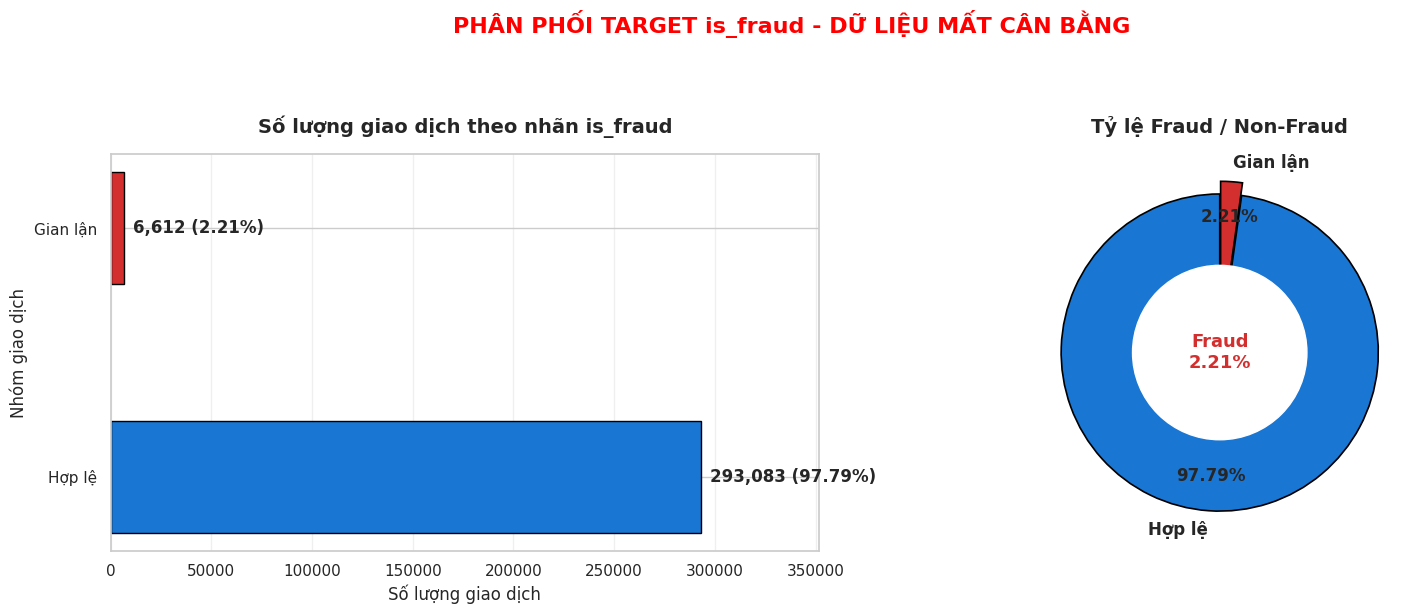

NHẬN XÉT PHÂN PHỐI TARGET
Số giao dịch hợp lệ: 293,083
Số giao dịch gian lận: 6,612
Tỷ lệ fraud: 2.2062%
Imbalance Ratio: 1 fraud : 44.3 giao dịch hợp lệ
→ Dữ liệu mất cân bằng mạnh.
→ Không nên dùng Accuracy làm metric chính.
→ Nên ưu tiên Recall, F2-score, PR-AUC và MCC.
→ Có thể xử lý bằng class_weight, scale_pos_weight và threshold tuning.


In [18]:
# ============================================================
# 4.1. EDA TARGET - PHÂN PHỐI is_fraud
# ============================================================

TARGET = TARGET_COL if "TARGET_COL" in globals() else "is_fraud"

eda_df = df_processed.copy() if "df_processed" in globals() else df.copy()

if TARGET not in eda_df.columns:
    raise ValueError(
        f"Không tìm thấy cột target '{TARGET}' trong dataframe. "
        f"Các cột hiện có là: {eda_df.columns.tolist()}"
    )

# Đếm số lượng từng lớp, cố định thứ tự 0 -> 1
fraud_count = eda_df[TARGET].value_counts().reindex([0, 1], fill_value=0)
fraud_pct = eda_df[TARGET].value_counts(normalize=True).reindex([0, 1], fill_value=0) * 100

target_distribution_df = pd.DataFrame({
    "Class": [0, 1],
    "Label": ["Hợp lệ", "Gian lận"],
    "Count": fraud_count.values,
    "Rate_%": fraud_pct.values
})

display(target_distribution_df)

# ============================================================
# VẼ BIỂU ĐỒ: BAR NGANG + DONUT CHART
# ============================================================

fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(16, 6)
)

colors = ["#1976D2", "#D32F2F"]

# ============================================================
# 1. BIỂU ĐỒ CỘT NGANG
# ============================================================

bars = axes[0].barh(
    target_distribution_df["Label"],
    target_distribution_df["Count"],
    color=colors,
    edgecolor="black",
    height=0.45
)
max_count = target_distribution_df["Count"].max()

for i, row in target_distribution_df.iterrows():
    axes[0].text(
        row["Count"] + max_count * 0.015,
        i,
        f'{int(row["Count"]):,} ({row["Rate_%"]:.2f}%)',
        va="center",
        ha="left",
        fontweight="bold",
        fontsize=12
    )
axes[0].set_xlim(0, max_count * 1.20)

axes[0].set_title(
    "Số lượng giao dịch theo nhãn is_fraud",
    fontsize=14,
    fontweight="bold",
    pad=15
)

axes[0].set_xlabel("Số lượng giao dịch")
axes[0].set_ylabel("Nhóm giao dịch")
axes[0].grid(axis="x", alpha=0.3)

# ============================================================
# 2. DONUT CHART
# ============================================================

wedges, texts, autotexts = axes[1].pie(
    fraud_count.values,
    labels=["Hợp lệ", "Gian lận"],
    colors=colors,
    startangle=90,
    explode=(0, 0.08),
    autopct="%1.2f%%",
    pctdistance=0.78,
    labeldistance=1.12,
    textprops={
        "fontsize": 12,
        "fontweight": "bold"
    },
    wedgeprops={
        "edgecolor": "black",
        "linewidth": 1.2
    }
)
centre_circle = plt.Circle(
    (0, 0),
    0.55,
    fc="white"
)

axes[1].add_artist(centre_circle)

axes[1].set_title(
    "Tỷ lệ Fraud / Non-Fraud",
    fontsize=14,
    fontweight="bold",
    pad=15
)
axes[1].text(
    0,
    0,
    f"Fraud\n{fraud_pct.loc[1]:.2f}%",
    ha="center",
    va="center",
    fontsize=13,
    fontweight="bold",
    color="#D32F2F"
)

# ============================================================
# TITLE CHUNG
# ============================================================

plt.suptitle(
    "PHÂN PHỐI TARGET is_fraud - DỮ LIỆU MẤT CÂN BẰNG",
    fontsize=16,
    fontweight="bold",
    color="red",
    y=1.02
)

plt.tight_layout(rect=[0, 0, 1, 0.95])

plt.savefig(
    "01_class_distribution.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

# ============================================================
# NHẬN XÉT TỰ ĐỘNG
# ============================================================

non_fraud = fraud_count.loc[0]
fraud = fraud_count.loc[1]

if fraud == 0:
    print("Không có giao dịch gian lận trong dữ liệu.")
else:
    imbalance_ratio = non_fraud / fraud

    print("=" * 80)
    print("NHẬN XÉT PHÂN PHỐI TARGET")
    print("=" * 80)
    print(f"Số giao dịch hợp lệ: {non_fraud:,}")
    print(f"Số giao dịch gian lận: {fraud:,}")
    print(f"Tỷ lệ fraud: {fraud_pct.loc[1]:.4f}%")
    print(f"Imbalance Ratio: 1 fraud : {imbalance_ratio:.1f} giao dịch hợp lệ")

    if fraud_pct.loc[1] < 10:
        print("→ Dữ liệu mất cân bằng mạnh.")
    else:
        print("→ Dữ liệu có mất cân bằng nhưng không quá nghiêm trọng.")

    print("→ Không nên dùng Accuracy làm metric chính.")
    print("→ Nên ưu tiên Recall, F2-score, PR-AUC và MCC.")
    print("→ Có thể xử lý bằng class_weight, scale_pos_weight và threshold tuning.")

## 4.2. Phân tích outlier bằng IQR

Với mỗi biến số, notebook tính:

$$
IQR=Q_3-Q_1
$$

$$
\mathrm{Lower}=Q_1-1.5IQR
$$

$$
\mathrm{Upper}=Q_3+1.5IQR
$$

Một quan sát nằm ngoài hai ngưỡng trên được đánh dấu là outlier.

Trong bài toán gian lận, outlier không được xóa tự động vì giao dịch lớn, khoảng cách xa hoặc hành vi bất thường có thể chính là tín hiệu cần phát hiện. Bảng và biểu đồ ở bước này dùng để đo mức độ bất thường, không phải để loại bỏ toàn bộ các quan sát đó.


,Column,Q1,Q3,IQR,Lower_Bound,Upper_Bound,Outlier_Count,Outlier_Rate_%
3,amount,42.10,191.11,149.01,-181.415,414.625,26711,8.912728
2,avg_amount_user,46.19,173.45,127.26,-144.700,364.340,23890,7.971438
4,shipping_distance_km,136.60,409.18,272.58,-272.270,818.050,20312,6.777557
0,account_age_days,516.00,1425.00,909.00,-847.500,2788.500,0,0.000000
1,total_transactions_user,46.00,56.00,10.00,31.000,71.000,0,0.000000


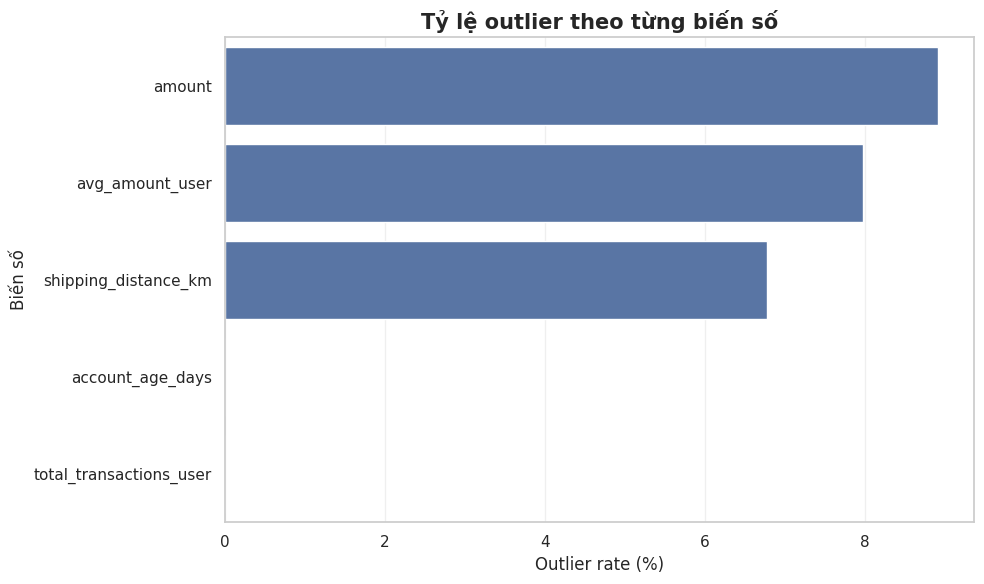

In [19]:
# ============================================================
# 4.2. OUTLIER ANALYSIS - PHÂN TÍCH OUTLIER
# ============================================================

numeric_for_outlier = [
    "account_age_days",
    "total_transactions_user",
    "avg_amount_user",
    "amount",
    "shipping_distance_km",
    "amount_ratio",
    "txn_per_account_day"
]

numeric_for_outlier = [
    col for col in numeric_for_outlier
    if col in df_processed.columns
]

outlier_rows = []

outlier_flag_df = df_processed[[TARGET_COL]].copy()

for col in numeric_for_outlier:
    Q1 = df_processed[col].quantile(0.25)
    Q3 = df_processed[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outlier_flag = (
        (df_processed[col] < lower) |
        (df_processed[col] > upper)
    )

    outlier_count = outlier_flag.sum()
    outlier_rate = outlier_count / len(df_processed) * 100

    outlier_flag_df[col + "_is_outlier"] = outlier_flag.astype(int)

    outlier_rows.append({
        "Column": col,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Lower_Bound": lower,
        "Upper_Bound": upper,
        "Outlier_Count": outlier_count,
        "Outlier_Rate_%": outlier_rate
    })

outlier_df = pd.DataFrame(outlier_rows)
outlier_df = outlier_df.sort_values("Outlier_Rate_%", ascending=False)

display(outlier_df)

# ============================================================
# BIỂU ĐỒ TỶ LỆ OUTLIER THEO TỪNG BIẾN
# ============================================================

plt.figure(figsize=(10, 6))

sns.barplot(
    data=outlier_df,
    x="Outlier_Rate_%",
    y="Column"
)

plt.title(
    "Tỷ lệ outlier theo từng biến số",
    fontsize=15,
    fontweight="bold"
)
plt.xlabel("Outlier rate (%)")
plt.ylabel("Biến số")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

## 4.3. So sánh biến số theo target

Các biến số được thống kê riêng cho hai nhóm `is_fraud = 0` và `is_fraud = 1` bằng:

- mean;
- median;
- standard deviation;
- min;
- max.

Boxplot giúp so sánh vị trí trung tâm, độ phân tán và outlier của từng biến giữa hai lớp.

Khi đọc biểu đồ, cần chú ý:

- median của fraud có khác non-fraud không;
- nhóm fraud có phân tán lớn hơn không;
- các feature mới như `security_fail_count` có tách hai lớp tốt không;
- sự khác biệt có ổn định hay chỉ do một số ít outlier.


account_age_days                                 total_transactions_user                              avg_amount_user                                        amount                           \
                     mean median         std  min     max                    mean median       std   min   max            mean median         std   min      max        mean  median         std  min   
is_fraud                                                                                                                                                                                                
0              982.891642  987.0  519.370380  1.0  1890.0               50.688665   51.0  5.973937  40.0  60.0      148.180170  90.14  200.843570  3.52  4565.29  167.829976   89.84  273.644198  5.0   
1              552.577737  205.0  605.554976  1.0  1890.0               49.993194   50.0  6.045668  40.0  60.0      146.494155  87.25  177.849561  3.52  2024.16  590.961199  103.16  880.753262  1.0   

                   shipping_distance_km                                      log_amount                                         log_shipping_distance_km                                         \
               max                 mean   median          std   min      max       mean    median       std       min       max                     mean    median       std      min       max   
is_fraud                                                                                                                                                                                          
0         16994.74           339.704956  269.490   383.750165  0.00  2500.00   4.517523  4.509100  1.091401  1.791759  9.740718                 5.373231  5.600235  1.064512  0.00000  7.824446   
1          5716.46          1125.841016  626.305  1076.308104  0.16  3748.56   4.663533  4.645928  2.221371  0.693147  8.651280                 6.435789  6.441433  1.260193  0.14842  8.229394   

         security_score                          security_fail_count                           
                   mean median       std min max                mean median       std min max  
is_fraud                                                                                       
0              2.528052    3.0  0.829609   0   3            0.471948    0.0  0.829609   0   3  
1              1.016183    0.0  1.183335   0   3            1.983817    3.0  1.183335   0   3

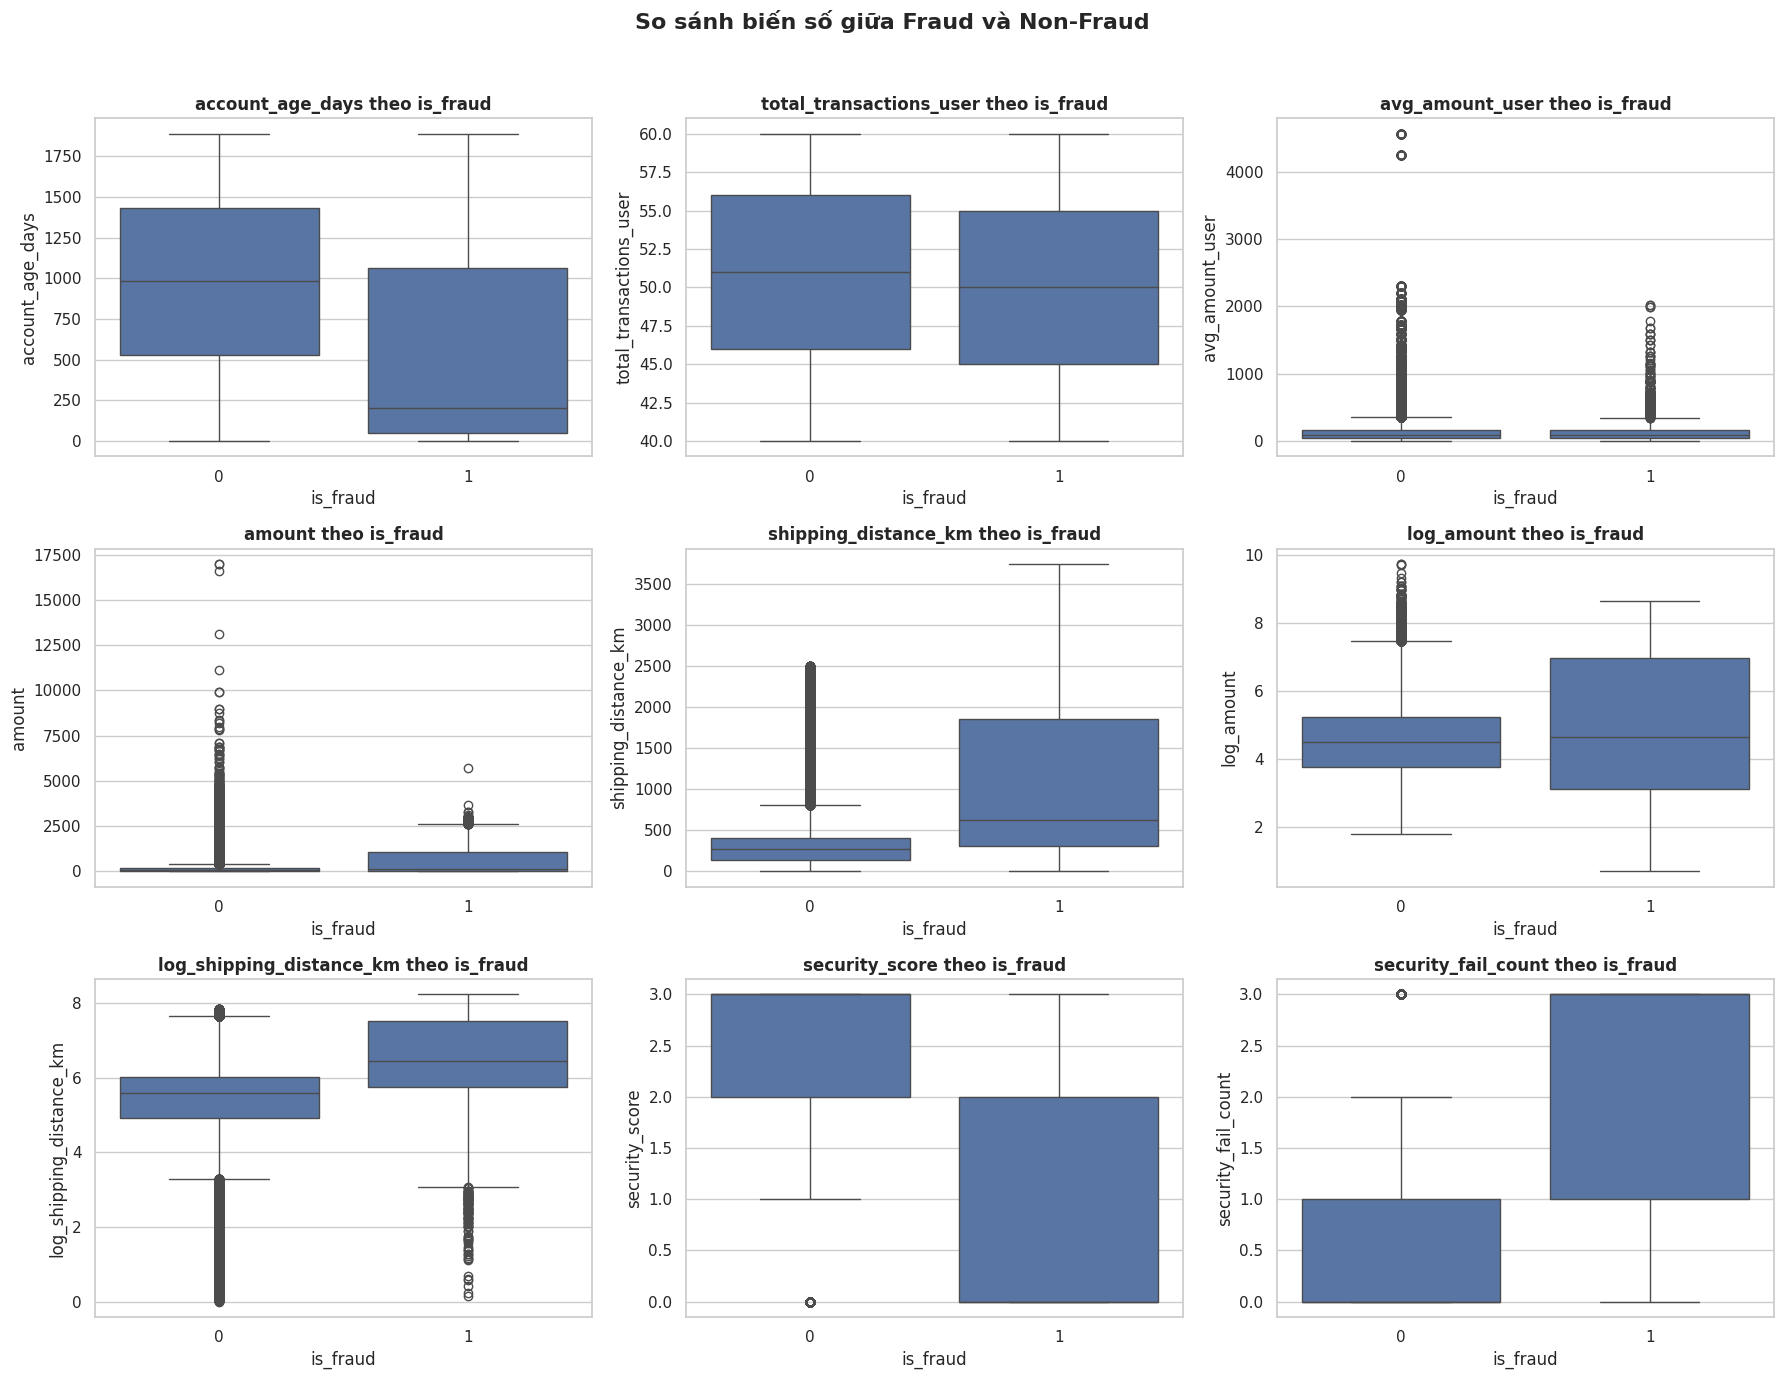

In [20]:
# ============================================================
# 4.3. EDA BIẾN SỐ THEO TARGET - DẠNG HÀNG NGANG
# ============================================================

numeric_eda_cols = [
    "account_age_days",
    "total_transactions_user",
    "avg_amount_user",
    "amount",
    "shipping_distance_km",
    "log_amount",
    "log_shipping_distance_km",
    "amount_ratio",
    "security_score",
    "security_fail_count",
    "txn_per_account_day"
]

numeric_eda_cols = [
    col for col in numeric_eda_cols
    if col in df_processed.columns
]

summary_by_target = df_processed.groupby(TARGET_COL)[numeric_eda_cols].agg(
    ["mean", "median", "std", "min", "max"]
)

display(summary_by_target)

n_plots = len(numeric_eda_cols)
n_cols = 3
n_rows = int(np.ceil(n_plots / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 4.5 * n_rows))
axes = np.array(axes).reshape(-1)

for ax, col in zip(axes, numeric_eda_cols):
    sns.boxplot(data=df_processed, x=TARGET_COL, y=col, ax=ax)
    ax.set_title(f"{col} theo is_fraud", fontweight="bold")
    ax.set_xlabel("is_fraud")
    ax.set_ylabel(col)

for ax in axes[n_plots:]:
    ax.set_visible(False)

plt.suptitle("So sánh biến số giữa Fraud và Non-Fraud", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## 4.4. So sánh trước và sau log-transform

Biểu đồ đặt phân phối gốc và phân phối sau log cạnh nhau.

Log-transform không xóa outlier mà chỉ nén khoảng cách giữa các giá trị lớn. Điều này đặc biệt có lợi cho Logistic Regression, vì mô hình tuyến tính dễ bị ảnh hưởng bởi phân phối lệch mạnh.

Nếu biểu đồ sau log cân đối hơn và phần đuôi phải ngắn hơn, phép biến đổi đã đạt mục tiêu.


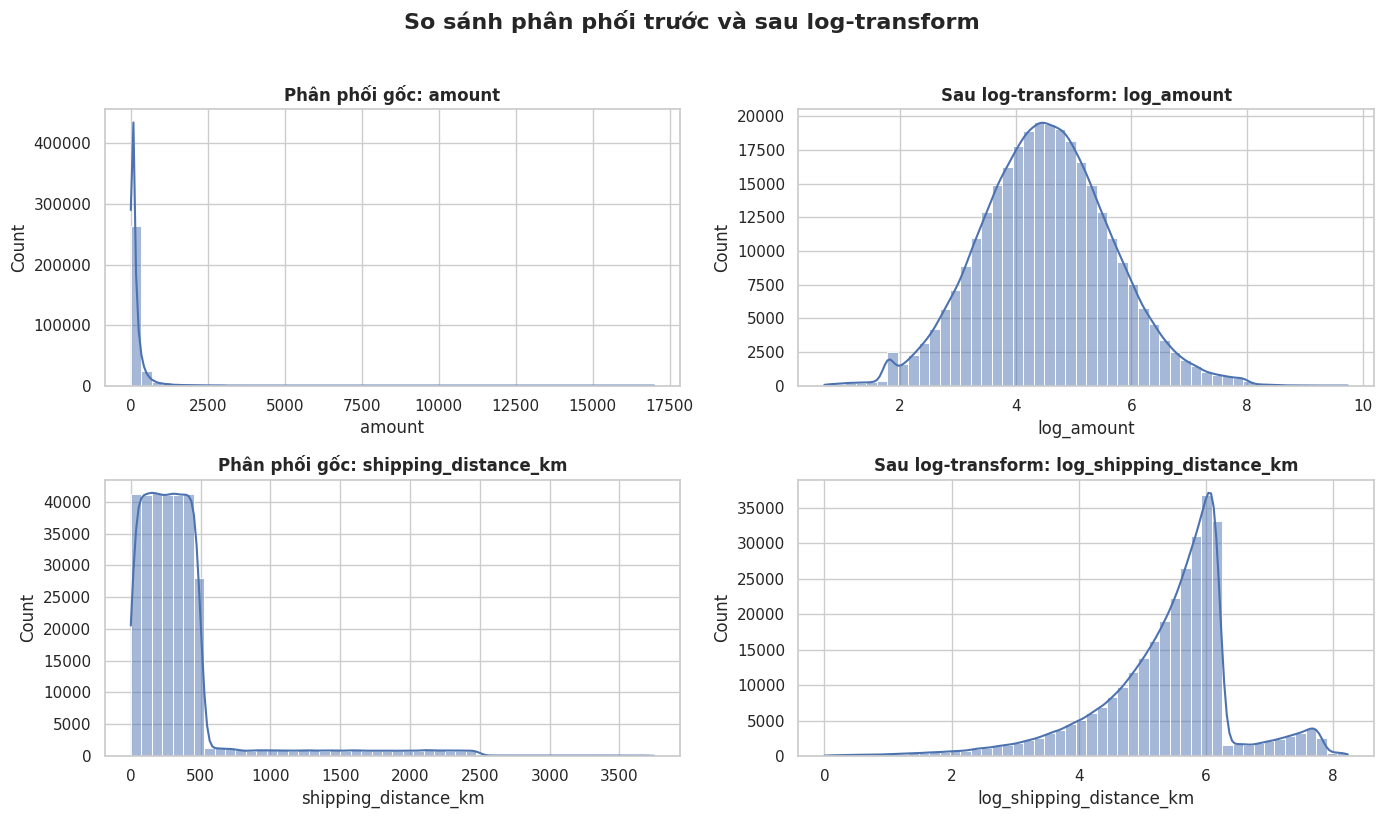

In [21]:
# ============================================================
# 4.4. SO SÁNH PHÂN PHỐI TRƯỚC / SAU LOG-TRANSFORM
# ============================================================

log_pairs = [
    ("amount", "log_amount"),
    ("avg_amount_user", "log_avg_amount_user"),
    ("shipping_distance_km", "log_shipping_distance_km"),
    ("amount_ratio", "log_amount_ratio")
]

log_pairs = [
    pair for pair in log_pairs
    if pair[0] in df_processed.columns and pair[1] in df_processed.columns
]

n_rows = len(log_pairs)

fig, axes = plt.subplots(n_rows, 2, figsize=(14, 4 * n_rows))

if n_rows == 1:
    axes = np.array([axes])

for i, (original_col, log_col) in enumerate(log_pairs):
    sns.histplot(df_processed[original_col], bins=50, kde=True, ax=axes[i, 0])
    axes[i, 0].set_title(f"Phân phối gốc: {original_col}", fontweight="bold")

    sns.histplot(df_processed[log_col], bins=50, kde=True, ax=axes[i, 1])
    axes[i, 1].set_title(f"Sau log-transform: {log_col}", fontweight="bold")

plt.suptitle("So sánh phân phối trước và sau log-transform", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## 4.5. Fraud rate theo biến phân loại và biến rủi ro

Với từng nhóm của một feature, fraud rate được tính bằng:

$$
\mathrm{Fraud\ Rate}
=
\frac{\text{số giao dịch fraud trong nhóm}}
{\text{tổng số giao dịch của nhóm}}
$$

Bảng hiển thị số giao dịch, số fraud và fraud rate; biểu đồ chỉ trình bày các nhóm nổi bật để tránh quá dày.

Fraud rate cao chỉ đáng tin khi nhóm có đủ số lượng quan sát. Vì vậy, cần xem đồng thời cả `total_transactions` và `fraud_rate_%`, không kết luận chỉ dựa trên tỷ lệ của một nhóm quá nhỏ.



Fraud rate theo country:


,country,total_transactions,fraud_count,fraud_rate,fraud_rate_%
8,tr,30074,843,0.028031,2.803086
7,ro,29501,709,0.024033,2.403308
6,pl,29965,701,0.023394,2.339396
1,es,28885,668,0.023126,2.312619
9,us,32430,748,0.023065,2.306506
2,fr,30343,664,0.021883,2.188314
4,it,28615,607,0.021213,2.121265
3,gb,30602,648,0.021175,2.117509
5,nl,30220,539,0.017836,1.783587
0,de,29060,485,0.016690,1.668961



Fraud rate theo bin_country:


,bin_country,total_transactions,fraud_count,fraud_rate,fraud_rate_%
8,tr,29972,781,0.026058,2.605765
6,pl,29963,699,0.023329,2.332877
7,ro,29532,679,0.022992,2.299201
1,es,29058,666,0.022920,2.291968
4,it,28709,641,0.022327,2.232749
9,us,32295,711,0.022016,2.201579
3,gb,30563,666,0.021791,2.179105
2,fr,30261,654,0.021612,2.161198
5,nl,30256,592,0.019566,1.956637
0,de,29086,523,0.017981,1.798116



Fraud rate theo channel:


...

,three_ds_flag,total_transactions,fraud_count,fraud_rate,fraud_rate_%
0,0,64558,4359,0.067521,6.752068
1,1,235137,2253,0.009582,0.958165



Fraud rate theo country_mismatch:


,country_mismatch,total_transactions,fraud_count,fraud_rate,fraud_rate_%
1,1,23730,2676,0.112769,11.276865
0,0,275965,3936,0.014263,1.426268



Fraud rate theo amount_5x_avg:


,amount_5x_avg,total_transactions,fraud_count,fraud_rate,fraud_rate_%
1,1,1673,1503,0.898386,89.838613
0,0,298022,5109,0.017143,1.714303


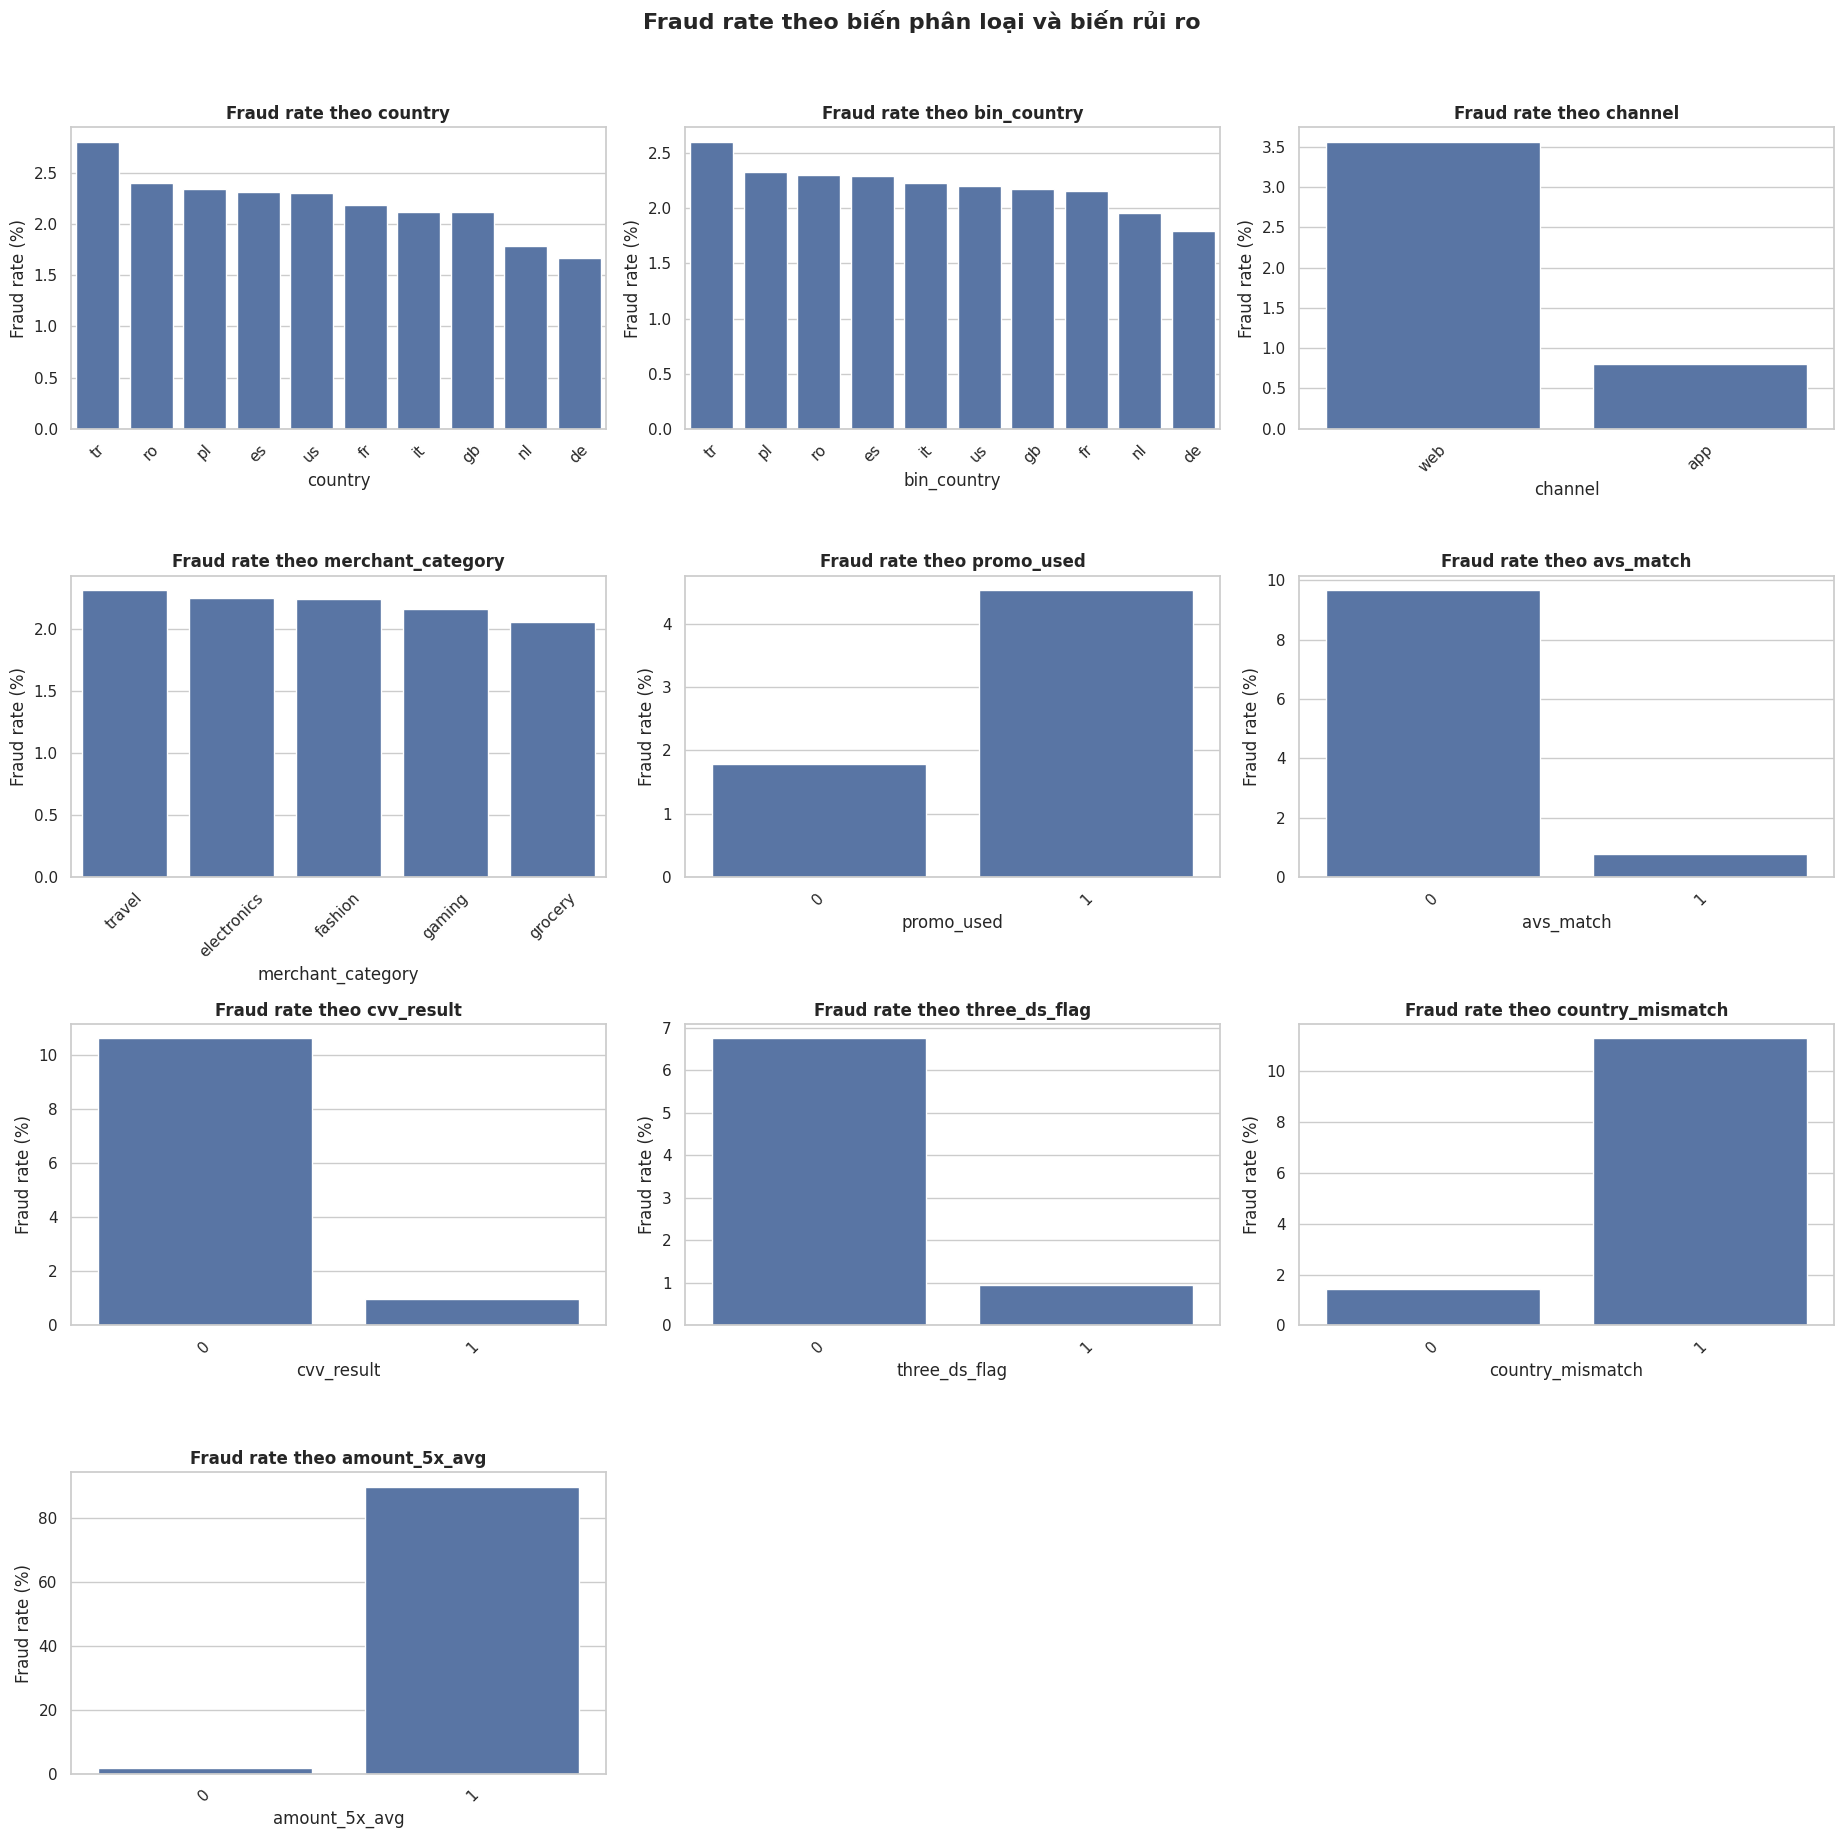

In [22]:
# ============================================================
# 4.5. EDA BIẾN PHÂN LOẠI / BIẾN RỦI RO THEO FRAUD RATE
# ============================================================

categorical_eda_cols = [
    "country",
    "bin_country",
    "channel",
    "merchant_category",
    "promo_used",
    "avs_match",
    "cvv_result",
    "three_ds_flag",
    "country_mismatch",
    "security_fail_all",
    "amount_2x_avg",
    "amount_5x_avg",
    "is_new_account_30d",
    "shipping_gt_1000km"
]

categorical_eda_cols = [
    col for col in categorical_eda_cols
    if col in df_processed.columns
]

fraud_rate_tables = {}

for col in categorical_eda_cols:
    table = (
        df_processed.groupby(col)[TARGET_COL]
        .agg(["count", "sum", "mean"])
        .reset_index()
    )

    table.columns = [
        col,
        "total_transactions",
        "fraud_count",
        "fraud_rate"
    ]

    table["fraud_rate_%"] = table["fraud_rate"] * 100
    table = table.sort_values("fraud_rate_%", ascending=False)

    fraud_rate_tables[col] = table

    print("\n" + "=" * 80)
    print(f"Fraud rate theo {col}:")
    display(table)

n_plots = len(categorical_eda_cols)
n_cols = 3
n_rows = int(np.ceil(n_plots / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6.2 * n_cols, 4.5 * n_rows))
axes = np.array(axes).reshape(-1)

for ax, col in zip(axes, categorical_eda_cols):
    table = fraud_rate_tables[col].head(10)

    sns.barplot(data=table, x=col, y="fraud_rate_%", ax=ax)
    ax.set_title(f"Fraud rate theo {col}", fontweight="bold")
    ax.set_xlabel(col)
    ax.set_ylabel("Fraud rate (%)")
    ax.tick_params(axis="x", rotation=45)

for ax in axes[n_plots:]:
    ax.set_visible(False)

plt.suptitle("Fraud rate theo biến phân loại và biến rủi ro", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## 4.6. Fraud Lift và Relative Risk

Lift so sánh fraud rate của một nhóm với fraud rate trung bình toàn dữ liệu:

$$
\mathrm{Lift}
=
\frac{\mathrm{Fraud\ Rate\ của\ nhóm}}
{\mathrm{Fraud\ Rate\ trung\ bình}}
$$

- `Lift = 1`: rủi ro tương đương mức trung bình;
- `Lift > 1`: nhóm có rủi ro cao hơn trung bình;
- `Lift < 1`: nhóm có rủi ro thấp hơn trung bình.

Lift giúp xếp hạng các nhóm rủi ro theo mức tăng tương đối, thay vì chỉ nhìn tỷ lệ fraud tuyệt đối.


,Feature,Risk_Group,Total_Transactions,Fraud_Count,Fraud_Rate_%,Lift_vs_Average
9,amount_5x_avg,1.0,1673.0,1503.0,89.838613,40.720180
8,country_mismatch,1.0,23730.0,2676.0,11.276865,5.111343
6,cvv_result,0.0,38328.0,4065.0,10.605823,4.807187
5,avs_match,0.0,48551.0,4693.0,9.666124,4.381260
7,three_ds_flag,0.0,64558.0,4359.0,6.752068,3.060437
4,promo_used,1.0,46045.0,2085.0,4.528179,2.052439
2,channel,web,152226.0,5426.0,3.564437,1.615614
0,country,tr,30074.0,843.0,2.803086,1.270524
1,bin_country,tr,29972.0,781.0,2.605765,1.181087
3,merchant_category,travel,59922.0,1388.0,2.316345,1.049905


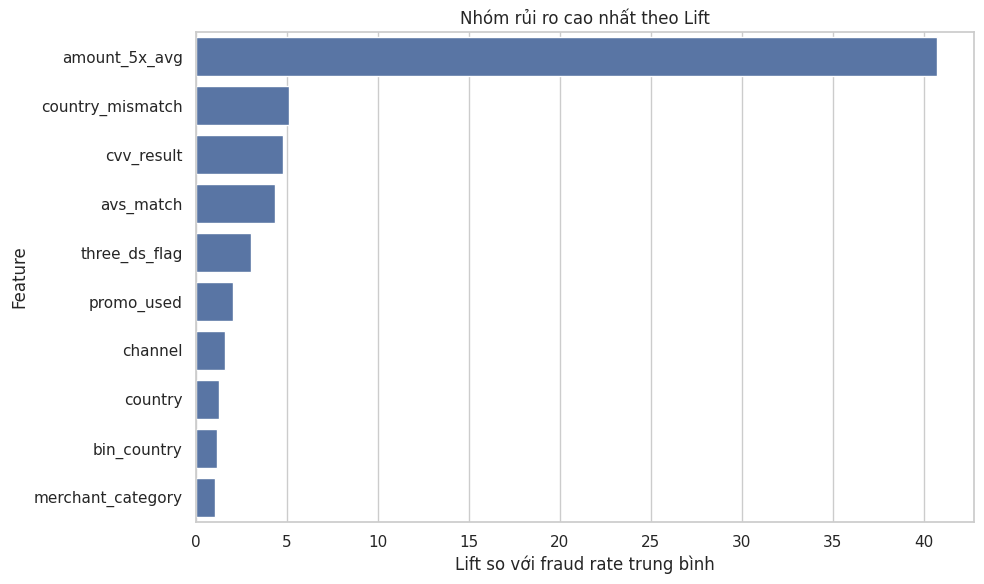

In [23]:
# ============================================================
# 4.6. FRAUD LIFT / RELATIVE RISK
# ============================================================

overall_fraud_rate = df_processed[TARGET_COL].mean()

lift_rows = []

for col in categorical_eda_cols:
    table = (
        df_processed.groupby(col)[TARGET_COL]
        .agg(["count", "sum", "mean"])
        .reset_index()
    )

    table.columns = [col, "total_transactions", "fraud_count", "fraud_rate"]
    table["fraud_rate_%"] = table["fraud_rate"] * 100
    table["lift_vs_average"] = table["fraud_rate"] / overall_fraud_rate

    table = table.sort_values("lift_vs_average", ascending=False)

    top_row = table.iloc[0]

    lift_rows.append({
        "Feature": col,
        "Risk_Group": top_row[col],
        "Total_Transactions": top_row["total_transactions"],
        "Fraud_Count": top_row["fraud_count"],
        "Fraud_Rate_%": top_row["fraud_rate_%"],
        "Lift_vs_Average": top_row["lift_vs_average"]
    })

top_lift_df = pd.DataFrame(lift_rows).sort_values("Lift_vs_Average", ascending=False)
display(top_lift_df)

plt.figure(figsize=(10, 6))
sns.barplot(data=top_lift_df, x="Lift_vs_Average", y="Feature")
plt.title("Nhóm rủi ro cao nhất theo Lift")
plt.xlabel("Lift so với fraud rate trung bình")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

## 4.7. Heatmap tương tác rủi

Heatmap tương tác được sử dụng để phân tích fraud rate khi hai điều kiện cùng xuất hiện.
Giá trị trong mỗi ô là:

$$
\mathrm{Fraud\ Rate}\times100
$$

Heatmap này kiểm tra fraud rate khi **hai điều kiện cùng xuất hiện**, ví dụ:

- điểm bảo mật và giao dịch lớn gấp 5 lần trung bình;
- quốc gia không khớp và trạng thái 3DS;
- tài khoản mới và giao dịch lớn;
- khoảng cách vận chuyển xa và xác thực bảo mật mạnh.

Các ô đã được bổ sung số bằng:

- `annot=True`: hiển thị trực tiếp giá trị;
- `fmt=".2f"`: làm tròn hai chữ số thập phân.

Màu càng đậm và giá trị càng lớn thì nhóm kết hợp đó có fraud rate càng cao. Heatmap giúp phát hiện tương tác mà phân tích từng biến riêng lẻ có thể bỏ sót.


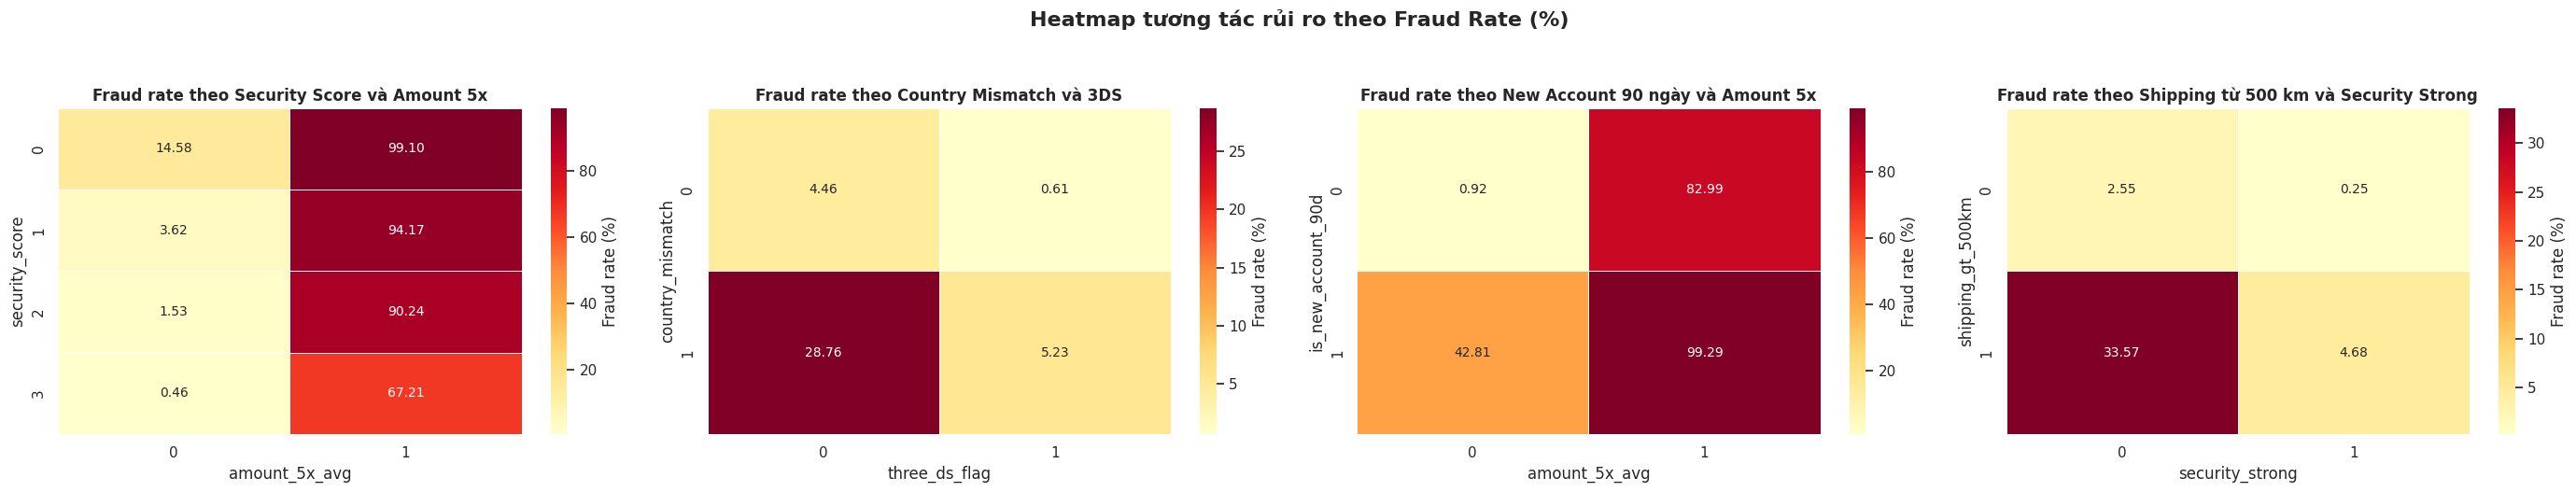

In [24]:
# ============================================================
# 4.7. HEATMAP TƯƠNG TÁC RỦI RO - CÓ HIỂN THỊ SỐ
# ============================================================

risk_pairs = [
    (
        "security_score",
        "amount_5x_avg",
        "Fraud rate theo Security Score và Amount 5x"
    ),
    (
        "country_mismatch",
        "three_ds_flag",
        "Fraud rate theo Country Mismatch và 3DS"
    ),
    (
        "is_new_account_90d",
        "amount_5x_avg",
        "Fraud rate theo New Account 90 ngày và Amount 5x"
    ),
    (
        "shipping_gt_500km",
        "security_strong",
        "Fraud rate theo Shipping từ 500 km và Security Strong"
    )
]

valid_pairs = [
    pair for pair in risk_pairs
    if pair[0] in df_processed.columns
    and pair[1] in df_processed.columns
]

n_plots = len(valid_pairs)

if n_plots > 0:
    fig, axes = plt.subplots(
        1,
        n_plots,
        figsize=(7 * n_plots, 5)
    )

    if n_plots == 1:
        axes = [axes]

    for ax, (row_col, col_col, title) in zip(axes, valid_pairs):
        pivot = df_processed.pivot_table(
            index=row_col,
            columns=col_col,
            values=TARGET_COL,
            aggfunc="mean"
        ) * 100

        sns.heatmap(
            pivot,
            annot=True,
            fmt=".2f",
            cmap="YlOrRd",
            linewidths=0.5,
            linecolor="white",
            annot_kws={"size": 10},
            cbar_kws={"label": "Fraud rate (%)"},
            ax=ax
        )

        ax.set_title(title, fontweight="bold")
        ax.set_xlabel(col_col)
        ax.set_ylabel(row_col)

    plt.suptitle(
        "Heatmap tương tác rủi ro theo Fraud Rate (%)",
        fontsize=16,
        fontweight="bold",
        y=1.05
    )
    plt.tight_layout()
    plt.show()
else:
    print("Không đủ cột để vẽ heatmap tương tác.")


## 4.8. Ma trận tương quan có hiển thị hệ số

Heatmap sử dụng hệ số tương quan Pearson:

$$
-1\leq r\leq 1
$$

- `r` gần `1`: tương quan thuận mạnh;
- `r` gần `-1`: tương quan nghịch mạnh;
- `r` gần `0`: quan hệ tuyến tính yếu.

`annot=True` và `fmt=".2f"` giúp hiển thị hệ số trực tiếp trên từng ô. Heatmap chỉ dùng các biến số gốc và feature mới quan trọng, không đưa toàn bộ cột One-Hot vào để tránh biểu đồ quá dày.

Lưu ý: tương quan thấp với `is_fraud` không đồng nghĩa feature vô ích. LightGBM và XGBoost còn có thể học quan hệ phi tuyến và tương tác giữa nhiều biến.


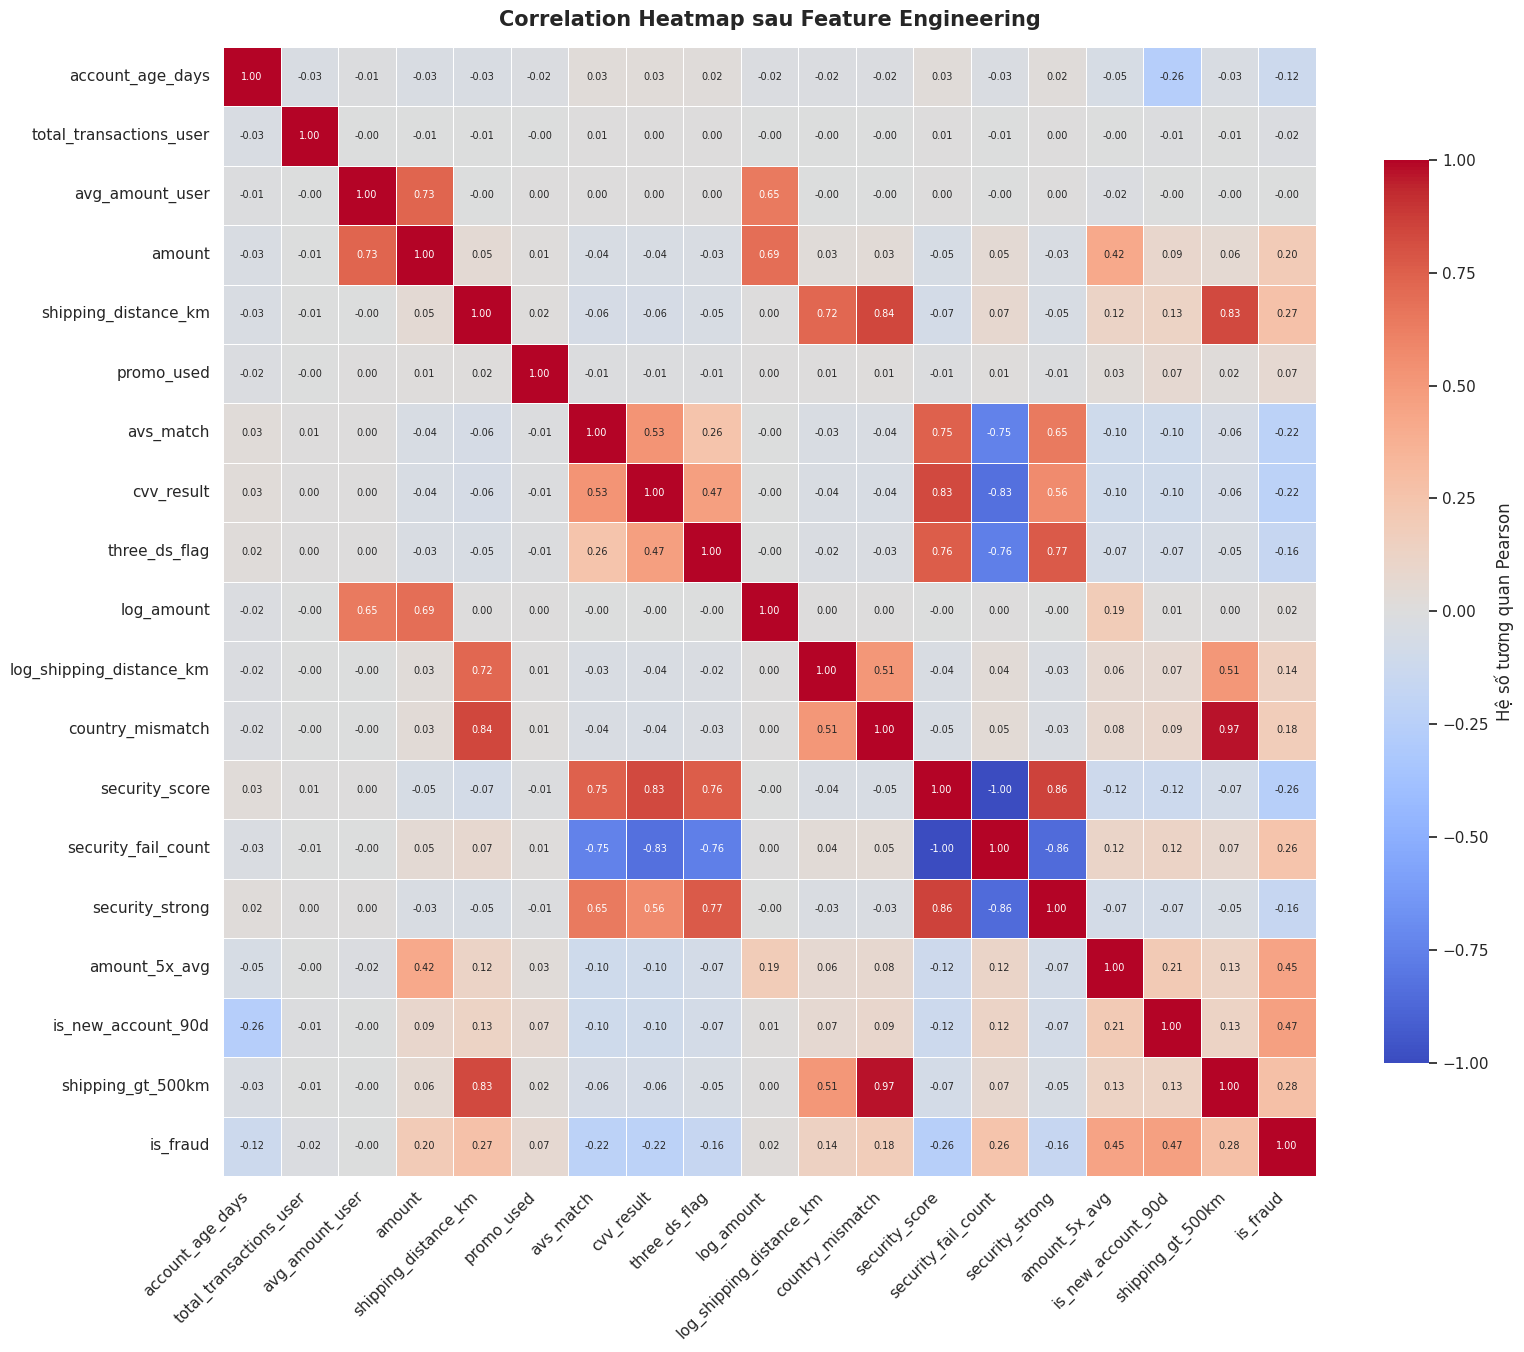

,Feature,Correlation_with_is_fraud
0,is_new_account_90d,0.4687
1,amount_5x_avg,0.4470
2,shipping_gt_500km,0.2812
3,shipping_distance_km,0.2700
4,security_score,-0.2559
5,security_fail_count,0.2559
6,avs_match,-0.2233
7,cvv_result,-0.2190
8,amount,0.2025
9,country_mismatch,0.1811


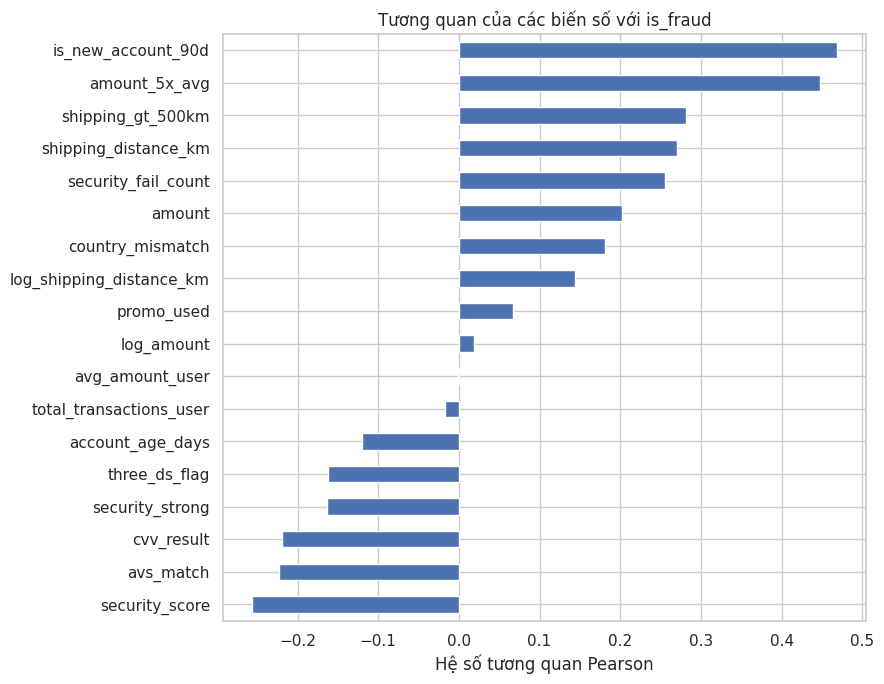

Lưu ý: tương quan Pearson thấp không đồng nghĩa feature không có tác dụng. LightGBM và XGBoost còn có thể học quan hệ phi tuyến và tương tác giữa nhiều biến.


In [25]:
# ============================================================
# 4.8. CORRELATION HEATMAP - CÓ HIỂN THỊ HỆ SỐ
# ============================================================

# Chỉ chọn các biến số gốc và feature mới quan trọng.
# Không đưa toàn bộ cột One-Hot vào heatmap để tránh biểu đồ quá dày.
corr_feature_candidates = [
    "account_age_days",
    "total_transactions_user",
    "avg_amount_user",
    "amount",
    "shipping_distance_km",
    "promo_used",
    "avs_match",
    "cvv_result",
    "three_ds_flag",
    "log_amount",
    "log_shipping_distance_km",
    "country_mismatch",
    "security_score",
    "security_fail_count",
    "security_strong",
    "amount_5x_avg",
    "is_new_account_90d",
    "shipping_gt_500km",
    TARGET_COL
]

numeric_cols_corr = [
    col for col in corr_feature_candidates
    if col in df_processed.columns
    and pd.api.types.is_numeric_dtype(df_processed[col])
]

corr = df_processed[numeric_cols_corr].corr(method="pearson")

n_corr = len(numeric_cols_corr)
fig_width = max(14, n_corr * 0.85)
fig_height = max(10, n_corr * 0.72)

plt.figure(figsize=(fig_width, fig_height))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    linecolor="white",
    annot_kws={"size": 7},
    cbar_kws={
        "shrink": 0.8,
        "label": "Hệ số tương quan Pearson"
    }
)

plt.title(
    "Correlation Heatmap sau Feature Engineering",
    fontsize=15,
    fontweight="bold",
    pad=15
)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Bảng tương quan với target
target_corr = (
    corr[TARGET_COL]
    .drop(TARGET_COL)
    .sort_values(
        key=lambda values: values.abs(),
        ascending=False
    )
)

target_corr_df = target_corr.reset_index()
target_corr_df.columns = [
    "Feature",
    "Correlation_with_is_fraud"
]

display(target_corr_df.round(4))

# Biểu đồ tương quan với target
plt.figure(figsize=(9, 7))
target_corr.sort_values().plot(kind="barh")
plt.title("Tương quan của các biến số với is_fraud")
plt.xlabel("Hệ số tương quan Pearson")
plt.ylabel("")
plt.tight_layout()
plt.show()

print(
    "Lưu ý: tương quan Pearson thấp không đồng nghĩa feature không có tác dụng. "
    "LightGBM và XGBoost còn có thể học quan hệ phi tuyến và tương tác giữa nhiều biến."
)


# 5. Chia tập dữ liệu

Dữ liệu được chia ngẫu nhiên có phân tầng bằng `stratify`:

- **Train:** 70%;
- **Validation:** 15%;
- **Test:** 15%.

`stratify` giữ tỷ lệ fraud gần tương đương giữa ba tập.

Vai trò của từng tập:

- **Train:** huấn luyện tham số mô hình;
- **Validation:** tuning threshold, Optuna và chọn champion;
- **Test:** báo cáo khả năng tổng quát hóa cuối cùng.

Việc chia theo index bảo đảm `X_ohe`, `X_scaled` và `y` sử dụng đúng cùng một tập quan sát.


In [26]:
# ============================================================
# 5. CHIA TRAIN / VALIDATION / TEST
# ============================================================

# Split theo index để đồng bộ X_ohe, X_scaled, y
all_indices = X_ohe.index

train_idx, temp_idx, y_train, y_temp = train_test_split(
    all_indices,
    y_full,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=y_full
)

valid_idx, test_idx, y_valid, y_test = train_test_split(
    temp_idx,
    y_temp,
    test_size=0.50,
    random_state=RANDOM_STATE,
    stratify=y_temp
)

# Tree models dùng X_ohe
X_train_tree = X_ohe.loc[train_idx]
X_valid_tree = X_ohe.loc[valid_idx]
X_test_tree = X_ohe.loc[test_idx]

# Logistic Regression dùng X_scaled
X_train_scaled = X_scaled.loc[train_idx]
X_valid_scaled = X_scaled.loc[valid_idx]
X_test_scaled = X_scaled.loc[test_idx]

# Đưa y về cùng index
y_train = y_full.loc[train_idx]
y_valid = y_full.loc[valid_idx]
y_test = y_full.loc[test_idx]

split_df = pd.DataFrame({
    "Dataset": ["Train", "Validation", "Test"],
    "Rows": [len(X_train_tree), len(X_valid_tree), len(X_test_tree)],
    "Fraud_Count": [int(y_train.sum()), int(y_valid.sum()), int(y_test.sum())],
    "Fraud_Rate_%": [
        y_train.mean() * 100,
        y_valid.mean() * 100,
        y_test.mean() * 100
    ]
})

display(split_df)

assert len(X_train_tree) == len(y_train)
assert len(X_valid_tree) == len(y_valid)
assert len(X_test_tree) == len(y_test)

print("X_train_tree:", X_train_tree.shape)
print("X_valid_tree:", X_valid_tree.shape)
print("X_test_tree:", X_test_tree.shape)

,Dataset,Rows,Fraud_Count,Fraud_Rate_%
0,Train,209786,4628,2.206058
1,Validation,44954,992,2.206700
2,Test,44955,992,2.206651


X_train_tree: (209786, 45)
X_valid_tree: (44954, 45)
X_test_tree: (44955, 45)


# 6. Xây dựng hàm đánh giá và threshold tuning

Mô hình trả về xác suất fraud. Nhãn cuối cùng được tạo theo:

$$
\hat{y}=
\begin{cases}
1,& P(y=1\mid x)\geq t\\
0,& P(y=1\mid x)<t
\end{cases}
$$

Trong đó, `t` là threshold.

Các metric chính:

$$
\mathrm{Precision}=\frac{TP}{TP+FP}
$$

$$
\mathrm{Recall}=\frac{TP}{TP+FN}
$$

$$
F_2=
\frac{5\cdot \mathrm{Precision}\cdot \mathrm{Recall}}
{4\cdot \mathrm{Precision}+\mathrm{Recall}}
$$

F2-score coi Recall quan trọng gấp bốn lần Precision trong công thức, phù hợp khi bỏ sót fraud gây hậu quả lớn.

Notebook còn tính chi phí:

$$
\mathrm{Cost}=10FN+1FP
$$

Threshold được quét từ `0.001` đến `0.999`. Nếu nhiều threshold có F2 bằng nhau, notebook ưu tiên MCC cao, Recall cao và Cost thấp hơn.


In [27]:
# ============================================================
# 6. ĐỊNH NGHĨA HÀM ĐÁNH GIÁ VÀ HÀM TÌM THRESHOLD
# ============================================================

def evaluate_model_at_threshold(
    model_name,
    y_true,
    y_prob,
    threshold,
    dataset_name="Validation"
):
    y_pred = (y_prob >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    cost = fn * 10 + fp

    return {
        "Dataset": dataset_name,
        "Model": model_name,
        "Threshold": float(threshold),
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "F2": fbeta_score(y_true, y_pred, beta=2, zero_division=0),
        "MCC": matthews_corrcoef(y_true, y_pred),
        "ROC_AUC": roc_auc_score(y_true, y_prob),
        "PR_AUC": average_precision_score(y_true, y_prob),
        "TN": int(tn),
        "FP": int(fp),
        "FN": int(fn),
        "TP": int(tp),
        "Cost_FN10_FP1": int(cost)
    }


def threshold_search(y_true, y_prob):
    thresholds = np.arange(
        THRESHOLD_MIN,
        THRESHOLD_MAX + 1e-9,
        THRESHOLD_STEP
    )

    rows = []

    for th in thresholds:
        y_pred = (y_prob >= th).astype(int)

        tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

        rows.append({
            "threshold": th,
            "Precision": precision_score(y_true, y_pred, zero_division=0),
            "Recall": recall_score(y_true, y_pred, zero_division=0),
            "F1": f1_score(y_true, y_pred, zero_division=0),
            "F2": fbeta_score(y_true, y_pred, beta=2, zero_division=0),
            "MCC": matthews_corrcoef(y_true, y_pred),
            "FP": int(fp),
            "FN": int(fn),
            "TP": int(tp),
            "TN": int(tn),
            "Cost_FN10_FP1": int(fn * 10 + fp)
        })

    threshold_df = pd.DataFrame(rows)

    best_row = (
        threshold_df
        .sort_values(
            by=["F2", "Cost_FN10_FP1", "MCC", "Precision"],
            ascending=[False, True, False, False]
        )
        .iloc[0]
    )

    best_threshold = float(best_row["threshold"])

    return best_threshold, threshold_df


def plot_threshold_curve(threshold_df, title):
    plt.figure(figsize=(11, 5))

    plt.plot(
        threshold_df["threshold"],
        threshold_df["Precision"],
        label="Precision",
        linewidth=2
    )

    plt.plot(
        threshold_df["threshold"],
        threshold_df["Recall"],
        label="Recall",
        linewidth=2
    )

    plt.plot(
        threshold_df["threshold"],
        threshold_df["F1"],
        label="F1-score",
        linewidth=2
    )

    plt.plot(
        threshold_df["threshold"],
        threshold_df["F2"],
        label="F2-score",
        linewidth=2
    )

    plt.plot(
        threshold_df["threshold"],
        threshold_df["MCC"],
        label="MCC",
        linewidth=2
    )

    best_f2_row = threshold_df.loc[
        threshold_df["F2"].idxmax()
    ]

    plt.axvline(
        best_f2_row["threshold"],
        linestyle="--",
        linewidth=2,
        label=f"Best F2 threshold = {best_f2_row['threshold']:.3f}"
    )

    plt.xlabel("Threshold")
    plt.ylabel("Score")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# 7. Xử lý mất cân bằng bằng trọng số lớp

`scale_pos_weight` được tính lại trên tập Train:

$$
\mathrm{scale\_pos\_weight}
=
\frac{N_0}{N_1}
$$

Trong đó:

- $N_0$: số giao dịch non-fraud trong Train;
- $N_1$: số giao dịch fraud trong Train.

Cách này không sinh thêm dữ liệu giả và không nhân bản quan sát. Thay vào đó, mô hình boosting chịu mức phạt lớn hơn khi phân loại sai lớp fraud.


In [28]:
# ============================================================
# 7. SCALE_POS_WEIGHT CHO DỮ LIỆU MẤT CÂN BẰNG
# ============================================================

neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()

scale_pos_weight = neg_count / max(pos_count, 1)

print("Non-fraud:", neg_count)
print("Fraud:", pos_count)
print("scale_pos_weight:", round(scale_pos_weight, 4))

Non-fraud: 205158
Fraud: 4628
scale_pos_weight: 44.3297


# 8. Huấn luyện và lưu kết quả mô hình

Hàm `train_evaluate_store()` thực hiện thống nhất các bước:

1. Fit mô hình trên Train;
2. Dự đoán xác suất trên Validation và Test;
3. Tìm threshold tốt nhất trên Validation;
4. Đánh giá Validation tại threshold đó;
5. Áp dụng nguyên threshold sang Test;
6. Lưu mô hình, threshold, xác suất và metric vào các dictionary.

Việc dùng một hàm chung giúp tất cả mô hình được đánh giá theo cùng quy trình và tránh sai khác do viết code riêng cho từng mô hình.

Champion vẫn được lựa chọn bằng kết quả Validation; kết quả Test chỉ được dùng ở phần báo cáo sau.


In [29]:
# ============================================================
# 8. HÀM TRAIN + THRESHOLD + EVALUATE
# ============================================================

trained_models = {}
model_thresholds = {}
valid_results = []
test_results = {}
valid_prob_store = {}
test_prob_store = {}

def train_evaluate_store(
    model_name,
    model,
    X_tr,
    y_tr,
    X_val,
    y_val,
    X_te,
    y_te,
    plot_curve=False
):
    print("\n" + "=" * 90)
    print("Training:", model_name)
    print("=" * 90)

    model.fit(X_tr, y_tr)

    valid_prob = model.predict_proba(X_val)[:, 1]
    test_prob = model.predict_proba(X_te)[:, 1]

    best_threshold, threshold_df = threshold_search(y_val, valid_prob)

    valid_result = evaluate_model_at_threshold(
        model_name,
        y_val,
        valid_prob,
        best_threshold,
        dataset_name="Validation"
    )

    test_result = evaluate_model_at_threshold(
        model_name,
        y_te,
        test_prob,
        best_threshold,
        dataset_name="Test"
    )

    trained_models[model_name] = model
    model_thresholds[model_name] = best_threshold
    valid_prob_store[model_name] = valid_prob
    test_prob_store[model_name] = test_prob
    valid_results.append(valid_result)
    test_results[model_name] = test_result

    print("Best threshold:", round(best_threshold, 6))
    display(pd.DataFrame([valid_result]))

    if plot_curve:
        plot_threshold_curve(
            threshold_df,
            title=f"{model_name} - Threshold tuning trên Validation"
        )

    return model

## 8.1. Các mô hình baseline

Các mô hình cơ bản tạo mốc so sánh:

### Dummy Classifier

Luôn dự đoán lớp phổ biến nhất. Nếu mô hình học máy không tốt hơn Dummy thì pipeline chưa học được tín hiệu hữu ích.

### Logistic Regression

Xác suất được tính theo:

$$
P(y=1\mid x)=\frac{1}{1+e^{-z}}
$$

Mô hình dùng dữ liệu đã scaling và `class_weight="balanced"`.

### Decision Tree

Học các luật chia nhánh phi tuyến. `max_depth=8` giới hạn độ phức tạp để giảm overfitting.

### Random Forest

Kết hợp nhiều cây được huấn luyện trên các mẫu và feature khác nhau. Dự đoán cuối là tổng hợp của toàn bộ rừng. `class_weight="balanced_subsample"` giúp mỗi cây chú ý hơn đến lớp fraud.



Training: DummyClassifier
Best threshold: 0.001


,Dataset,Model,Threshold,Accuracy,Precision,Recall,F1,F2,MCC,ROC_AUC,PR_AUC,TN,FP,FN,TP,Cost_FN10_FP1
0,Validation,DummyClassifier,0.001,0.977933,0.0,0.0,0.0,0.0,0.0,0.5,0.022067,43962,0,992,0,9920



Training: Logistic Regression
Best threshold: 0.885


,Dataset,Model,Threshold,Accuracy,Precision,Recall,F1,F2,MCC,ROC_AUC,PR_AUC,TN,FP,FN,TP,Cost_FN10_FP1
0,Validation,Logistic Regression,0.885,0.987943,0.700535,0.792339,0.743614,0.772102,0.738931,0.975953,0.829736,43626,336,206,786,2396


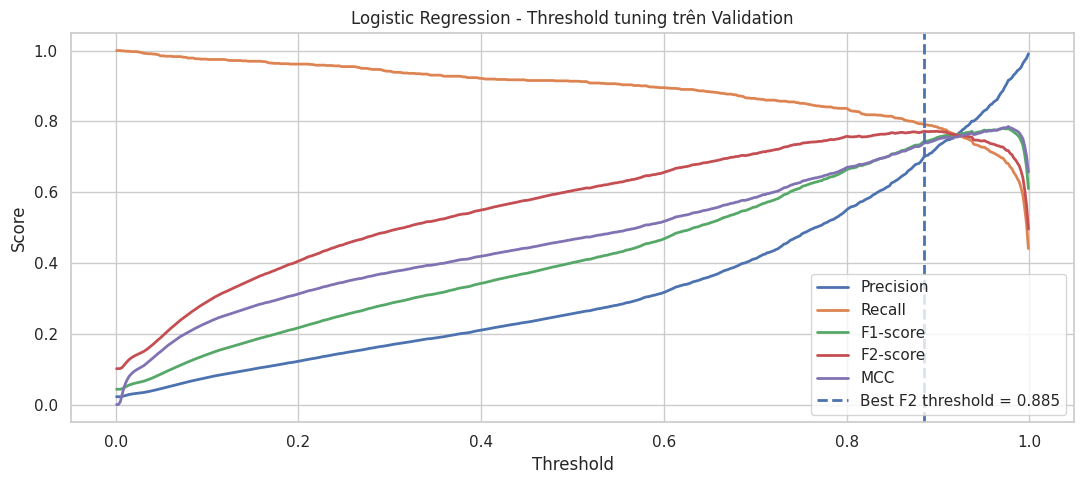


Training: Decision Tree
Best threshold: 0.947


,Dataset,Model,Threshold,Accuracy,Precision,Recall,F1,F2,MCC,ROC_AUC,PR_AUC,TN,FP,FN,TP,Cost_FN10_FP1
0,Validation,Decision Tree,0.947,0.990791,0.788423,0.796371,0.792377,0.794769,0.787678,0.960974,0.829296,43750,212,202,790,2232



Training: Random Forest
Best threshold: 0.329


,Dataset,Model,Threshold,Accuracy,Precision,Recall,F1,F2,MCC,ROC_AUC,PR_AUC,TN,FP,FN,TP,Cost_FN10_FP1
0,Validation,Random Forest,0.329,0.991191,0.785441,0.826613,0.805501,0.818037,0.801271,0.974533,0.859411,43738,224,172,820,1944


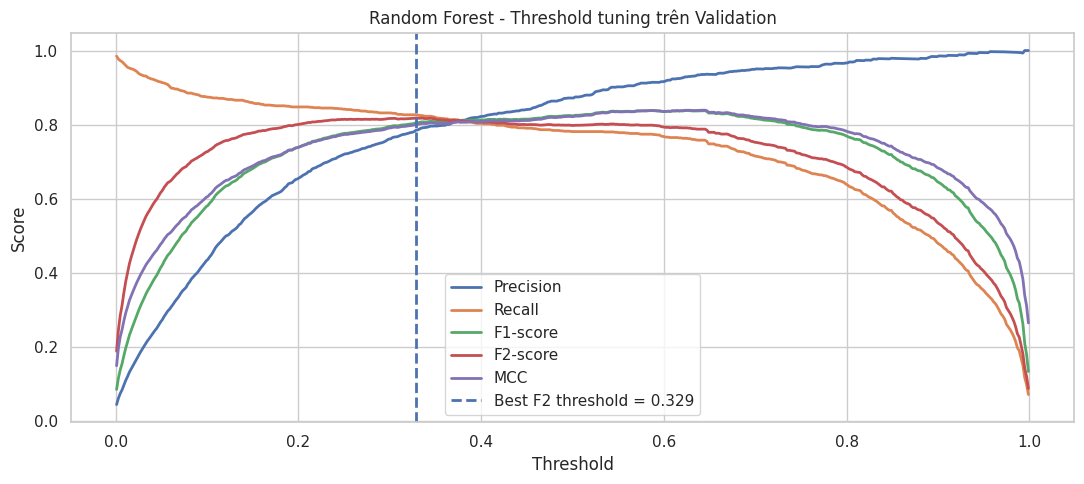

,Dataset,Model,Threshold,Accuracy,Precision,Recall,F1,F2,MCC,ROC_AUC,PR_AUC,TN,FP,FN,TP,Cost_FN10_FP1
3,Validation,Random Forest,0.329,0.991191,0.785441,0.826613,0.805501,0.818037,0.801271,0.974533,0.859411,43738,224,172,820,1944
2,Validation,Decision Tree,0.947,0.990791,0.788423,0.796371,0.792377,0.794769,0.787678,0.960974,0.829296,43750,212,202,790,2232
1,Validation,Logistic Regression,0.885,0.987943,0.700535,0.792339,0.743614,0.772102,0.738931,0.975953,0.829736,43626,336,206,786,2396
0,Validation,DummyClassifier,0.001,0.977933,0.000000,0.000000,0.000000,0.000000,0.000000,0.500000,0.022067,43962,0,992,0,9920


In [30]:
# ============================================================
# 8.1. BASELINE MODELS
# ============================================================

# Dummy
dummy_model = DummyClassifier(
    strategy="most_frequent",
    random_state=RANDOM_STATE
)

train_evaluate_store(
    "DummyClassifier",
    dummy_model,
    X_train_tree,
    y_train,
    X_valid_tree,
    y_valid,
    X_test_tree,
    y_test
)

# Logistic Regression dùng dữ liệu scaled
log_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

train_evaluate_store(
    "Logistic Regression",
    log_model,
    X_train_scaled,
    y_train,
    X_valid_scaled,
    y_valid,
    X_test_scaled,
    y_test,
    plot_curve=True
)

# Decision Tree
dt_model = DecisionTreeClassifier(
    max_depth=8,
    class_weight="balanced",
    random_state=RANDOM_STATE
)

train_evaluate_store(
    "Decision Tree",
    dt_model,
    X_train_tree,
    y_train,
    X_valid_tree,
    y_valid,
    X_test_tree,
    y_test
)

# Random Forest
rf_model = RandomForestClassifier(
    n_estimators=400,
    min_samples_leaf=2,
    max_features="sqrt",
    class_weight="balanced_subsample",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

train_evaluate_store(
    "Random Forest",
    rf_model,
    X_train_tree,
    y_train,
    X_valid_tree,
    y_valid,
    X_test_tree,
    y_test,
    plot_curve=True
)

baseline_valid_df = pd.DataFrame(valid_results).sort_values(
    by=["F2", "PR_AUC", "Recall"],
    ascending=False
)

display(baseline_valid_df)

## 8.2. LightGBM Base và XGBoost Base

Hai mô hình boosting xây dựng cây theo tuần tự. Mỗi cây mới tập trung sửa lỗi của các cây trước.

Dự đoán tổng quát có dạng:

$$
F(x)=\sum_{k=1}^{K}f_k(x)
$$

Trong cấu hình base:

- `learning_rate` nhỏ giúp cập nhật thận trọng;
- `n_estimators` tương đối lớn để bù cho learning rate nhỏ;
- `subsample` và `colsample_bytree` giảm overfitting;
- `reg_alpha`, `reg_lambda` tạo regularization;
- `scale_pos_weight` xử lý mất cân bằng.

Đây là các cấu hình khởi đầu trước khi tối ưu bằng Optuna.



Training: LightGBM Base
Best threshold: 0.787


,Dataset,Model,Threshold,Accuracy,Precision,Recall,F1,F2,MCC,ROC_AUC,PR_AUC,TN,FP,FN,TP,Cost_FN10_FP1
0,Validation,LightGBM Base,0.787,0.990279,0.754354,0.829637,0.790206,0.813402,0.786173,0.978283,0.864546,43694,268,169,823,1958


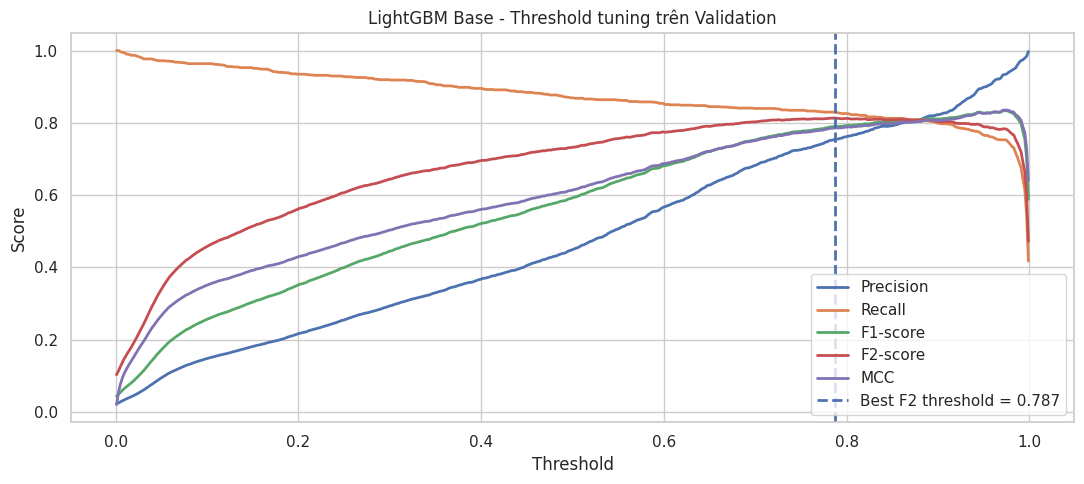


Training: XGBoost Base
Best threshold: 0.835


,Dataset,Model,Threshold,Accuracy,Precision,Recall,F1,F2,MCC,ROC_AUC,PR_AUC,TN,FP,FN,TP,Cost_FN10_FP1
0,Validation,XGBoost Base,0.835,0.990057,0.747053,0.830645,0.786635,0.812463,0.782711,0.978369,0.869895,43683,279,168,824,1959


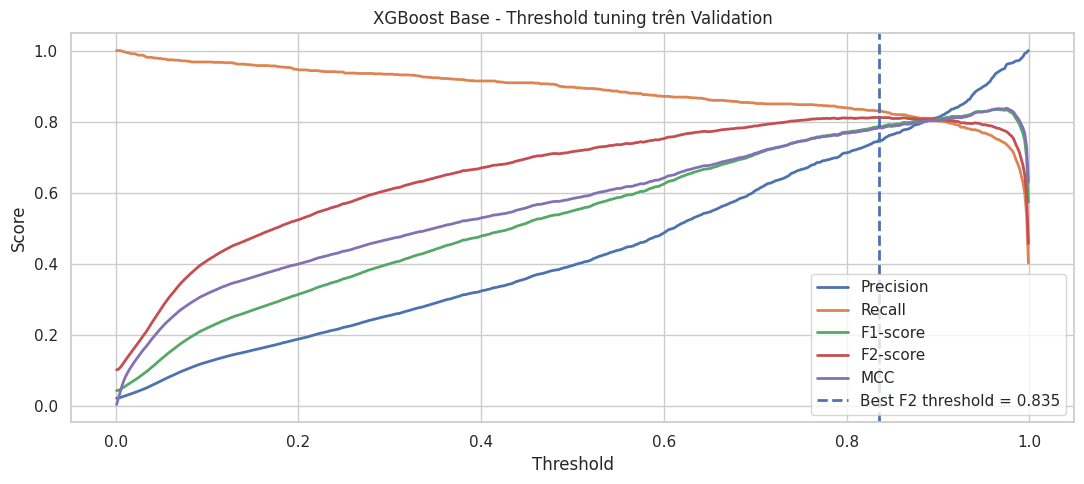

,Dataset,Model,Threshold,Accuracy,Precision,Recall,F1,F2,MCC,ROC_AUC,PR_AUC,TN,FP,FN,TP,Cost_FN10_FP1
3,Validation,Random Forest,0.329,0.991191,0.785441,0.826613,0.805501,0.818037,0.801271,0.974533,0.859411,43738,224,172,820,1944
4,Validation,LightGBM Base,0.787,0.990279,0.754354,0.829637,0.790206,0.813402,0.786173,0.978283,0.864546,43694,268,169,823,1958
5,Validation,XGBoost Base,0.835,0.990057,0.747053,0.830645,0.786635,0.812463,0.782711,0.978369,0.869895,43683,279,168,824,1959
2,Validation,Decision Tree,0.947,0.990791,0.788423,0.796371,0.792377,0.794769,0.787678,0.960974,0.829296,43750,212,202,790,2232
1,Validation,Logistic Regression,0.885,0.987943,0.700535,0.792339,0.743614,0.772102,0.738931,0.975953,0.829736,43626,336,206,786,2396
0,Validation,DummyClassifier,0.001,0.977933,0.000000,0.000000,0.000000,0.000000,0.000000,0.500000,0.022067,43962,0,992,0,9920


In [31]:
# ============================================================
# 8.2. LIGHTGBM BASE VÀ XGBOOST BASE
# ============================================================

lgbm_base = LGBMClassifier(
    n_estimators=700,
    learning_rate=0.03,
    num_leaves=31,
    min_child_samples=30,
    subsample=0.85,
    colsample_bytree=0.85,
    reg_alpha=0.1,
    reg_lambda=1.0,
    scale_pos_weight=scale_pos_weight,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbosity=-1
)

train_evaluate_store(
    "LightGBM Base",
    lgbm_base,
    X_train_tree,
    y_train,
    X_valid_tree,
    y_valid,
    X_test_tree,
    y_test,
    plot_curve=True
)

xgb_base = XGBClassifier(
    n_estimators=700,
    learning_rate=0.03,
    max_depth=5,
    min_child_weight=5,
    subsample=0.85,
    colsample_bytree=0.85,
    reg_alpha=0.1,
    reg_lambda=1.0,
    scale_pos_weight=scale_pos_weight,
    objective="binary:logistic",
    eval_metric="logloss",
    tree_method="hist",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

train_evaluate_store(
    "XGBoost Base",
    xgb_base,
    X_train_tree,
    y_train,
    X_valid_tree,
    y_valid,
    X_test_tree,
    y_test,
    plot_curve=True
)

base_valid_df = pd.DataFrame(valid_results).sort_values(
    by=["F2", "PR_AUC", "Recall"],
    ascending=False
)

display(base_valid_df)

# 9. Tối ưu siêu tham số bằng Optuna

## 9.1. Optuna cho LightGBM

Optuna thử nhiều tổ hợp siêu tham số như:

- số cây;
- learning rate;
- số lá;
- độ sâu;
- số mẫu tối thiểu trong lá;
- tỷ lệ lấy mẫu dòng và cột;
- regularization;
- `scale_pos_weight`.

Trong mỗi trial:

1. LightGBM được huấn luyện trên Train;
2. Xác suất được dự đoán trên Validation;
3. Threshold tốt nhất được tìm trên Validation;
4. Trial được chấm điểm chủ yếu bằng F2-score.

Hàm mục tiêu thực tế là:

$$
\mathrm{Score}
=
F_2
+
0.05\max(\mathrm{MCC},0)
-
10^{-6}\mathrm{Cost}
$$

Như vậy, F2 vẫn là tiêu chí chính, MCC và Cost chỉ đóng vai trò phụ để phân biệt các cấu hình gần nhau. Early stopping dừng huấn luyện khi Validation không còn cải thiện.


In [32]:
# ============================================================
# 9.1. OPTUNA LIGHTGBM - TỐI ƯU TRỰC TIẾP F2
# ============================================================

def objective_lgbm(trial):
    params = {
        "objective": "binary",
        "boosting_type": "gbdt",
        "n_estimators": trial.suggest_int("n_estimators", 400, 1600),
        "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.08, log=True),
        "num_leaves": trial.suggest_int("num_leaves", 16, 160),
        "max_depth": trial.suggest_categorical("max_depth", [-1, 4, 5, 6, 7, 8, 10, 12]),
        "min_child_samples": trial.suggest_int("min_child_samples", 10, 180),
        "min_child_weight": trial.suggest_float("min_child_weight", 1e-3, 10.0, log=True),
        "subsample": trial.suggest_float("subsample", 0.65, 1.0),
        "subsample_freq": trial.suggest_int("subsample_freq", 1, 7),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.65, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 20.0, log=True),
        "scale_pos_weight": trial.suggest_float(
            "scale_pos_weight",
            1.0,
            max(2.0, scale_pos_weight * 1.3)
        ),
        "random_state": RANDOM_STATE,
        "n_jobs": -1,
        "verbosity": -1
    }

    model = LGBMClassifier(**params)

    model.fit(
        X_train_tree,
        y_train,
        eval_set=[(X_valid_tree, y_valid)],
        eval_metric="binary_logloss",
        callbacks=[lgb.early_stopping(stopping_rounds=80, verbose=False)]
    )

    valid_prob = model.predict_proba(X_valid_tree)[:, 1]
    best_threshold, threshold_df = threshold_search(y_valid, valid_prob)

    best_row = threshold_df.loc[
        np.isclose(threshold_df["threshold"], best_threshold)
    ].iloc[0]

    score = (
        1.00 * best_row["F2"] +
        0.05 * max(best_row["MCC"], 0) -
        0.000001 * best_row["Cost_FN10_FP1"]
    )

    return score


study_lgbm = optuna.create_study(
    direction="maximize",
    study_name="lgbm_direct_f2"
)

study_lgbm.optimize(
    objective_lgbm,
    n_trials=N_TRIALS_LGBM,
    show_progress_bar=True
)

best_lgbm_params = study_lgbm.best_params.copy()
best_lgbm_params.update({
    "objective": "binary",
    "boosting_type": "gbdt",
    "random_state": RANDOM_STATE,
    "n_jobs": -1,
    "verbosity": -1
})

print("Best LightGBM Optuna score:", study_lgbm.best_value)
print("Best LightGBM params:")
display(best_lgbm_params)

  0%|          | 0/50 [00:00<?, ?it/s]

Best LightGBM Optuna score: 0.8605130852186674
Best LightGBM params:


{'n_estimators': 922,
 'learning_rate': 0.029730862639266917,
 'num_leaves': 27,
 'max_depth': -1,
 'min_child_samples': 178,
 'min_child_weight': 0.0040892939980306,
 'subsample': 0.7615633910534191,
 'subsample_freq': 7,
 'colsample_bytree': 0.7519266029295556,
 'reg_alpha': 1.35863248234166e-05,
 'reg_lambda': 0.006073014921306502,
 'scale_pos_weight': 1.329369318985872,
 'objective': 'binary',
 'boosting_type': 'gbdt',
 'random_state': 42,
 'n_jobs': -1,
 'verbosity': -1}

## 9.2. Huấn luyện LightGBM đã tối ưu

Sau khi Optuna tìm được bộ tham số tốt nhất, LightGBM được huấn luyện lại bằng cấu hình đó.

Mô hình tiếp tục sử dụng đúng quy trình đánh giá chung:

- tìm threshold trên Validation;
- tính metric Validation;
- áp dụng threshold sang Test;
- lưu mô hình và kết quả để so sánh cuối.



Training: LightGBM Optuna Tuned
Best threshold: 0.171


,Dataset,Model,Threshold,Accuracy,Precision,Recall,F1,F2,MCC,ROC_AUC,PR_AUC,TN,FP,FN,TP,Cost_FN10_FP1
0,Validation,LightGBM Optuna Tuned,0.171,0.99059,0.764651,0.828629,0.795356,0.814991,0.791217,0.978681,0.871387,43709,253,170,822,1953


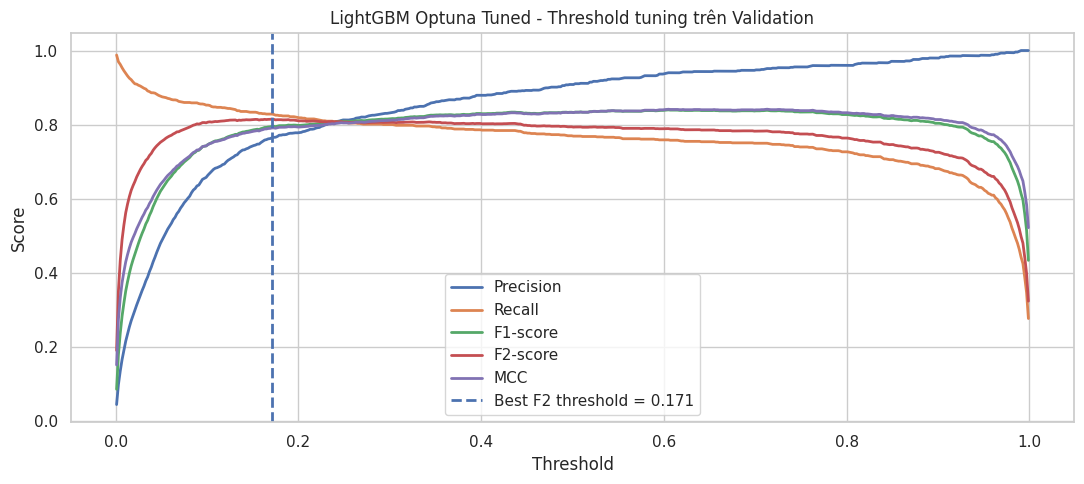

LGBMClassifier(colsample_bytree=0.7519266029295556,
               learning_rate=0.029730862639266917, min_child_samples=178,
               min_child_weight=0.0040892939980306, n_estimators=922, n_jobs=-1,
               num_leaves=27, objective='binary', random_state=42,
               reg_alpha=1.35863248234166e-05, reg_lambda=0.006073014921306502,
               scale_pos_weight=1.329369318985872, subsample=0.7615633910534191,
               subsample_freq=7, verbosity=-1)

In [33]:
# ============================================================
# 9.2. TRAIN LIGHTGBM TUNED
# ============================================================

lgbm_tuned = LGBMClassifier(**best_lgbm_params)

train_evaluate_store(
    "LightGBM Optuna Tuned",
    lgbm_tuned,
    X_train_tree,
    y_train,
    X_valid_tree,
    y_valid,
    X_test_tree,
    y_test,
    plot_curve=True
)

## 9.3. Optuna cho XGBoost

Không gian tìm kiếm của XGBoost gồm:

- `n_estimators`;
- `learning_rate`;
- `max_depth`;
- `min_child_weight`;
- `subsample`;
- `colsample_bytree`;
- `gamma`;
- `reg_alpha`, `reg_lambda`;
- `max_delta_step`;
- `scale_pos_weight`.

Mỗi trial được đánh giá trên Validation bằng cùng hàm mục tiêu kết hợp F2, MCC và Cost như LightGBM. Điều này giúp hai mô hình được tối ưu theo cùng mục tiêu nghiệp vụ.


In [34]:
# ============================================================
# 9.3. OPTUNA XGBOOST - TỐI ƯU TRỰC TIẾP F2
# ============================================================

def objective_xgb(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 400, 1400),
        "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.08, log=True),
        "max_depth": trial.suggest_int("max_depth", 3, 9),
        "min_child_weight": trial.suggest_float("min_child_weight", 1.0, 30.0, log=True),
        "subsample": trial.suggest_float("subsample", 0.65, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.65, 1.0),
        "gamma": trial.suggest_float("gamma", 0.0, 8.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 20.0, log=True),
        "max_delta_step": trial.suggest_float("max_delta_step", 0.0, 10.0),
        "scale_pos_weight": trial.suggest_float(
            "scale_pos_weight",
            1.0,
            max(2.0, scale_pos_weight * 1.3)
        ),
        "objective": "binary:logistic",
        "eval_metric": "logloss",
        "tree_method": "hist",
        "random_state": RANDOM_STATE,
        "n_jobs": -1
    }

    model = XGBClassifier(**params)

    model.fit(
        X_train_tree,
        y_train,
        eval_set=[(X_valid_tree, y_valid)],
        verbose=False
    )

    valid_prob = model.predict_proba(X_valid_tree)[:, 1]
    best_threshold, threshold_df = threshold_search(y_valid, valid_prob)

    best_row = threshold_df.loc[
        np.isclose(threshold_df["threshold"], best_threshold)
    ].iloc[0]

    score = (
        1.00 * best_row["F2"] +
        0.05 * max(best_row["MCC"], 0) -
        0.000001 * best_row["Cost_FN10_FP1"]
    )

    return score


study_xgb = optuna.create_study(
    direction="maximize",
    study_name="xgb_direct_f2"
)

study_xgb.optimize(
    objective_xgb,
    n_trials=N_TRIALS_XGB,
    show_progress_bar=True
)

best_xgb_params = study_xgb.best_params.copy()
best_xgb_params.update({
    "objective": "binary:logistic",
    "eval_metric": "logloss",
    "tree_method": "hist",
    "random_state": RANDOM_STATE,
    "n_jobs": -1
})

print("Best XGBoost Optuna score:", study_xgb.best_value)
print("Best XGBoost params:")
display(best_xgb_params)

  0%|          | 0/50 [00:00<?, ?it/s]

Best XGBoost Optuna score: 0.8618743506473435
Best XGBoost params:


{'n_estimators': 1125,
 'learning_rate': 0.00858319902906683,
 'max_depth': 4,
 'min_child_weight': 10.959699906178002,
 'subsample': 0.8037042529584342,
 'colsample_bytree': 0.7317333790590188,
 'gamma': 7.030230901199074,
 'reg_alpha': 0.0030074232302950686,
 'reg_lambda': 0.0742180827564327,
 'max_delta_step': 7.006907979518576,
 'scale_pos_weight': 8.408733153388939,
 'objective': 'binary:logistic',
 'eval_metric': 'logloss',
 'tree_method': 'hist',
 'random_state': 42,
 'n_jobs': -1}

## 9.4. Huấn luyện XGBoost đã tối ưu

Bộ tham số tốt nhất từ Optuna được dùng để tạo `XGBoost Optuna Tuned`.

Mô hình được huấn luyện lại trên Train, threshold được chọn trên Validation và kết quả được lưu cùng các mô hình khác. Bước này cho phép so sánh công bằng giữa mô hình base và mô hình đã tuning.



Training: XGBoost Optuna Tuned
Best threshold: 0.633


,Dataset,Model,Threshold,Accuracy,Precision,Recall,F1,F2,MCC,ROC_AUC,PR_AUC,TN,FP,FN,TP,Cost_FN10_FP1
0,Validation,XGBoost Optuna Tuned,0.633,0.991547,0.795367,0.830645,0.812623,0.823341,0.8085,0.979073,0.873324,43750,212,168,824,1892


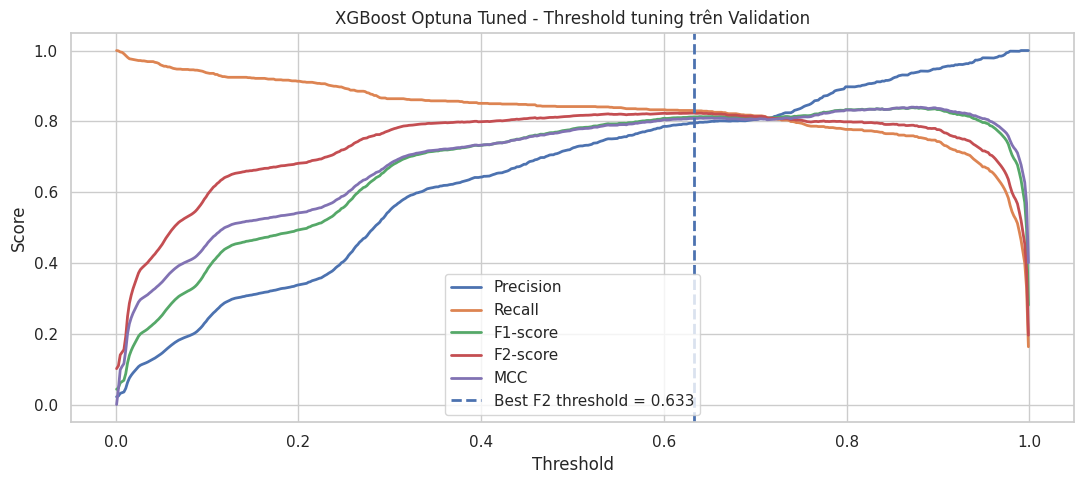

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.7317333790590188, device=None,
              early_stopping_rounds=None, enable_categorical=False,
              eval_metric='logloss', feature_types=None, feature_weights=None,
              gamma=7.030230901199074, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.00858319902906683,
              max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=7.006907979518576, max_depth=4, max_leaves=None,
              min_child_weight=10.959699906178002, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=1125,
              n_jobs=-1, num_parallel_tree=None, ...)

In [35]:
# ============================================================
# 9.4. TRAIN XGBOOST TUNED
# ============================================================

xgb_tuned = XGBClassifier(**best_xgb_params)

train_evaluate_store(
    "XGBoost Optuna Tuned",
    xgb_tuned,
    X_train_tree,
    y_train,
    X_valid_tree,
    y_valid,
    X_test_tree,
    y_test,
    plot_curve=True
)

# 10. So sánh mô hình và chọn Champion

Bảng Validation được sắp xếp lần lượt theo:

1. F2-score giảm dần;
2. PR-AUC giảm dần;
3. Recall giảm dần;
4. MCC giảm dần.

Mô hình đứng đầu được chọn làm champion. Threshold của champion cũng chính là threshold đã được tối ưu trên Validation.

Việc chọn bằng Validation giúp Test không tham gia vào quyết định mô hình. Biểu đồ F2-score cho thấy trực quan mức chênh lệch giữa các mô hình.


,Dataset,Model,Threshold,Precision,Recall,F1,F2,MCC,ROC_AUC,PR_AUC,FP,FN,TP,TN,Cost_FN10_FP1
0,Validation,XGBoost Optuna Tuned,0.633,0.7954,0.8306,0.8126,0.8233,0.8085,0.9791,0.8733,212,168,824,43750,1892
1,Validation,Random Forest,0.329,0.7854,0.8266,0.8055,0.8180,0.8013,0.9745,0.8594,224,172,820,43738,1944
2,Validation,LightGBM Optuna Tuned,0.171,0.7647,0.8286,0.7954,0.8150,0.7912,0.9787,0.8714,253,170,822,43709,1953
3,Validation,LightGBM Base,0.787,0.7544,0.8296,0.7902,0.8134,0.7862,0.9783,0.8645,268,169,823,43694,1958
4,Validation,XGBoost Base,0.835,0.7471,0.8306,0.7866,0.8125,0.7827,0.9784,0.8699,279,168,824,43683,1959
5,Validation,Decision Tree,0.947,0.7884,0.7964,0.7924,0.7948,0.7877,0.9610,0.8293,212,202,790,43750,2232
6,Validation,Logistic Regression,0.885,0.7005,0.7923,0.7436,0.7721,0.7389,0.9760,0.8297,336,206,786,43626,2396
7,Validation,DummyClassifier,0.001,0.0000,0.0000,0.0000,0.0000,0.0000,0.5000,0.0221,0,992,0,43962,9920


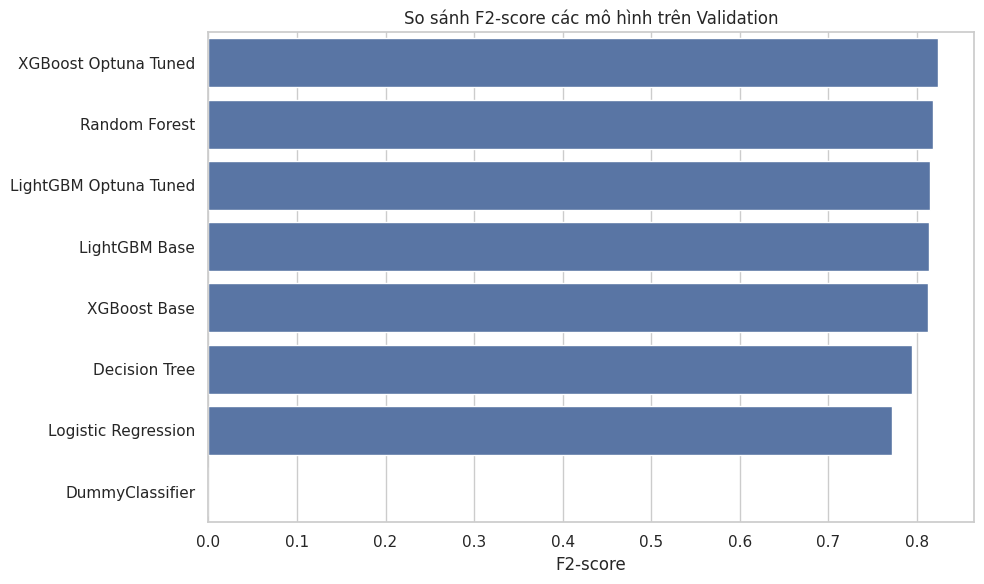

Champion model: XGBoost Optuna Tuned
Champion threshold: 0.633


,0
Dataset,Validation
Model,XGBoost Optuna Tuned
Threshold,0.633
Precision,0.795367
Recall,0.830645
F1,0.812623
F2,0.823341
MCC,0.8085
ROC_AUC,0.979073
PR_AUC,0.873324


In [36]:
# ============================================================
# 10. SO SÁNH MÔ HÌNH TRÊN VALIDATION
# ============================================================

valid_results_df = pd.DataFrame(valid_results)

show_cols = [
    "Dataset",
    "Model",
    "Threshold",
    "Precision",
    "Recall",
    "F1",
    "F2",
    "MCC",
    "ROC_AUC",
    "PR_AUC",
    "FP",
    "FN",
    "TP",
    "TN",
    "Cost_FN10_FP1"
]

valid_results_df = valid_results_df[show_cols].sort_values(
    by=["F2", "PR_AUC", "Recall", "MCC"],
    ascending=False
).reset_index(drop=True)

display(valid_results_df.round(4))

plt.figure(figsize=(10, 6))
sns.barplot(data=valid_results_df, x="F2", y="Model")
plt.title("So sánh F2-score các mô hình trên Validation")
plt.xlabel("F2-score")
plt.ylabel("")
plt.tight_layout()
plt.show()

# Chọn champion theo Validation
champion_name = valid_results_df.iloc[0]["Model"]
champion_threshold = float(valid_results_df.iloc[0]["Threshold"])
champion_model = trained_models[champion_name]

print("Champion model:", champion_name)
print("Champion threshold:", champion_threshold)
display(valid_results_df.iloc[0])

# 11. Đánh giá cuối cùng trên Test

Sau khi champion đã được chốt, threshold từ Validation được áp dụng nguyên trạng lên Test.

Bảng Test báo cáo:

- Precision;
- Recall;
- F1 và F2;
- MCC;
- ROC-AUC;
- PR-AUC;
- FP, FN, TP, TN;
- Cost.

Classification Report cung cấp thêm precision, recall và F1 của từng lớp. Kết quả Test phản ánh khả năng tổng quát hóa trên dữ liệu chưa dùng để lựa chọn champion.


In [37]:
# ============================================================
# 11. ĐÁNH GIÁ CUỐI TRÊN TEST SET
# ============================================================

test_rows = []

for model_name, result in test_results.items():
    test_rows.append(result)

test_results_df = pd.DataFrame(test_rows)
test_results_df = test_results_df[show_cols].sort_values(
    by=["F2", "PR_AUC", "Recall", "MCC"],
    ascending=False
).reset_index(drop=True)

display(test_results_df.round(4))

champion_test_prob = test_prob_store[champion_name]
champion_test_pred = (champion_test_prob >= champion_threshold).astype(int)

print("Champion model:", champion_name)
print("Champion threshold:", champion_threshold)
print("\nClassification Report trên Test:")
print(classification_report(y_test, champion_test_pred))

,Dataset,Model,Threshold,Precision,Recall,F1,F2,MCC,ROC_AUC,PR_AUC,FP,FN,TP,TN,Cost_FN10_FP1
0,Test,Random Forest,0.329,0.7929,0.8145,0.8036,0.8101,0.7992,0.9713,0.8541,211,184,808,43752,2051
1,Test,XGBoost Optuna Tuned,0.633,0.7957,0.8125,0.8040,0.8091,0.7996,0.9786,0.8659,207,186,806,43756,2067
2,Test,LightGBM Base,0.787,0.7682,0.8185,0.7926,0.8080,0.7882,0.9747,0.8623,245,180,812,43718,2045
3,Test,XGBoost Base,0.835,0.7637,0.8175,0.7897,0.8062,0.7852,0.9771,0.8650,251,181,811,43712,2061
4,Test,LightGBM Optuna Tuned,0.171,0.7674,0.8115,0.7888,0.8023,0.7842,0.9767,0.8654,244,187,805,43719,2114
5,Test,Decision Tree,0.947,0.7913,0.7873,0.7893,0.7881,0.7845,0.9649,0.8176,206,211,781,43757,2316
6,Test,Logistic Regression,0.885,0.6968,0.7692,0.7312,0.7535,0.7257,0.9732,0.8090,332,229,763,43631,2622
7,Test,DummyClassifier,0.001,0.0000,0.0000,0.0000,0.0000,0.0000,0.5000,0.0221,0,992,0,43963,9920


Champion model: XGBoost Optuna Tuned
Champion threshold: 0.633

Classification Report trên Test:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     43963
           1       0.80      0.81      0.80       992

    accuracy                           0.99     44955
   macro avg       0.90      0.90      0.90     44955
weighted avg       0.99      0.99      0.99     44955



## 12. So sánh các mô hình trên Test

Bốn biểu đồ được đặt trên cùng một hàng để so sánh:

- F2-score: hiệu quả tổng hợp, ưu tiên Recall;
- Recall: khả năng bắt fraud;
- Precision: mức chính xác của cảnh báo fraud;
- Cost: tổng chi phí theo quy tắc `10FN + FP`.

Mô hình tốt không nhất thiết đứng đầu mọi chỉ số. Với fraud detection, cần cân bằng giữa bắt được fraud và hạn chế cảnh báo nhầm.


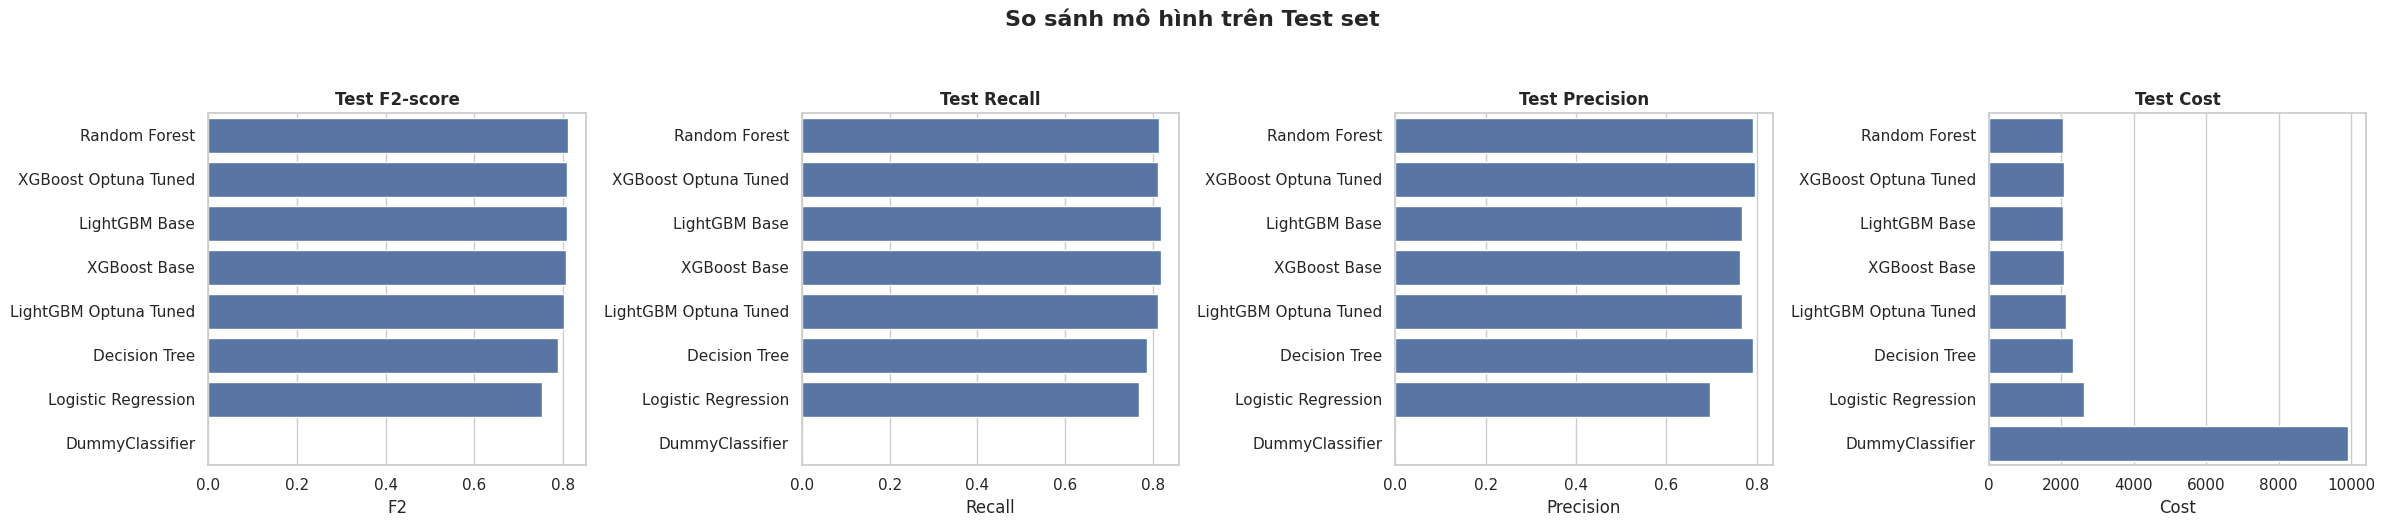

In [38]:
# ============================================================
# 12. BIỂU ĐỒ TEST: F2, RECALL, PRECISION, COST
# ============================================================

fig, axes = plt.subplots(1, 4, figsize=(24, 5))

sns.barplot(data=test_results_df, x="F2", y="Model", ax=axes[0])
axes[0].set_title("Test F2-score", fontweight="bold")
axes[0].set_xlabel("F2")
axes[0].set_ylabel("")

sns.barplot(data=test_results_df, x="Recall", y="Model", ax=axes[1])
axes[1].set_title("Test Recall", fontweight="bold")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("")

sns.barplot(data=test_results_df, x="Precision", y="Model", ax=axes[2])
axes[2].set_title("Test Precision", fontweight="bold")
axes[2].set_xlabel("Precision")
axes[2].set_ylabel("")

sns.barplot(data=test_results_df, x="Cost_FN10_FP1", y="Model", ax=axes[3])
axes[3].set_title("Test Cost", fontweight="bold")
axes[3].set_xlabel("Cost")
axes[3].set_ylabel("")

plt.suptitle("So sánh mô hình trên Test set", fontsize=16, fontweight="bold", y=1.05)
plt.tight_layout()
plt.show()

# 13. Phân tích chi tiết Champion

### Confusion Matrix

- **TP:** fraud được phát hiện đúng;
- **TN:** giao dịch hợp lệ được nhận diện đúng;
- **FP:** giao dịch hợp lệ bị cảnh báo nhầm;
- **FN:** fraud bị bỏ sót.

FN là lỗi nghiêm trọng hơn trong quy tắc chi phí của bài.

### ROC Curve

Biểu diễn quan hệ giữa True Positive Rate và False Positive Rate ở nhiều threshold. ROC-AUC hữu ích để đánh giá khả năng xếp hạng tổng quát.

### Precision–Recall Curve

Phù hợp hơn ROC Curve khi lớp fraud rất hiếm, vì tập trung trực tiếp vào chất lượng phát hiện lớp dương.


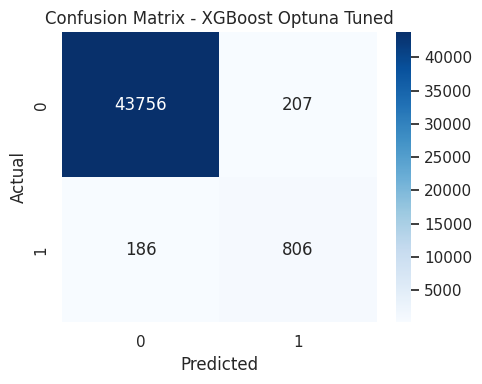

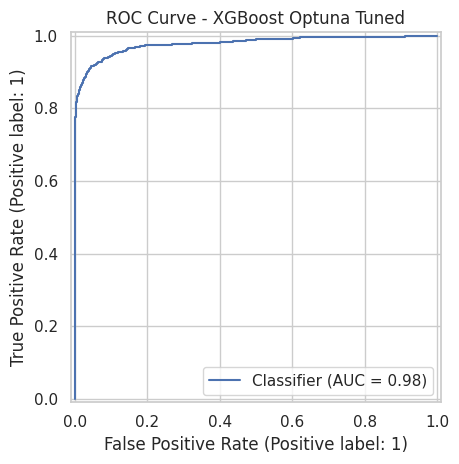

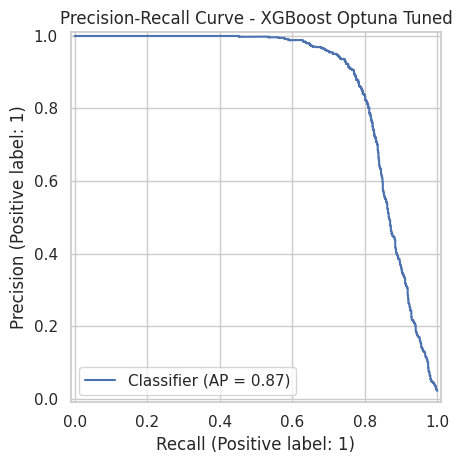

In [39]:
# ============================================================
# 13. CONFUSION MATRIX, ROC CURVE, PR CURVE CHO CHAMPION
# ============================================================

cm = confusion_matrix(y_test, champion_test_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title(f"Confusion Matrix - {champion_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

RocCurveDisplay.from_predictions(y_test, champion_test_prob)
plt.title(f"ROC Curve - {champion_name}")
plt.tight_layout()
plt.show()

PrecisionRecallDisplay.from_predictions(y_test, champion_test_prob)
plt.title(f"Precision-Recall Curve - {champion_name}")
plt.tight_layout()
plt.show()

# 14. Feature Importance

Nếu champion là mô hình cây, `feature_importances_` được dùng để xếp hạng các feature mà mô hình sử dụng nhiều nhất khi chia nhánh.

Feature Importance giúp trả lời:

- mô hình dựa nhiều vào biến nào;
- các feature mới có thực sự được sử dụng không;
- có feature dư thừa hoặc gần như không đóng góp không.

Lưu ý: importance cao không chứng minh quan hệ nhân quả. Khi hai feature tương quan mạnh, importance có thể được chia sẻ hoặc dồn vào một feature.


,Feature,Importance
16,is_new_account_90d,0.226725
5,avs_match,0.156661
17,shipping_gt_500km,0.122233
13,security_fail_count,0.080597
12,security_score,0.077141
15,amount_5x_avg,0.057832
0,account_age_days,0.034648
11,country_mismatch,0.033090
14,security_strong,0.028638
3,amount,0.022458


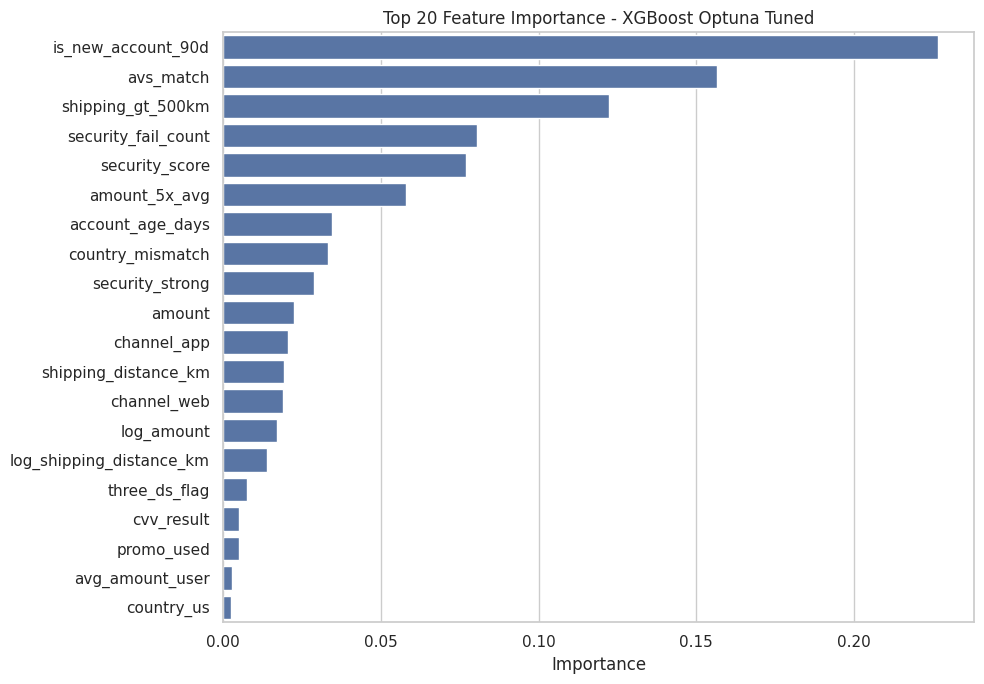

In [40]:
# ============================================================
# 14. FEATURE IMPORTANCE CHO CHAMPION
# ============================================================

if hasattr(champion_model, "feature_importances_"):
    importance_df = pd.DataFrame({
        "Feature": X_train_tree.columns,
        "Importance": champion_model.feature_importances_
    }).sort_values("Importance", ascending=False)

    display(importance_df.head(30))

    plt.figure(figsize=(10, 7))
    sns.barplot(data=importance_df.head(20), x="Importance", y="Feature")
    plt.title(f"Top 20 Feature Importance - {champion_name}")
    plt.xlabel("Importance")
    plt.ylabel("")
    plt.tight_layout()
    plt.show()
else:
    print("Champion model không có feature_importances_.")

# 15. Demo dự đoán giao dịch thật từ Test

Notebook không tự tạo một giao dịch giả. Thay vào đó, hàm tìm:

- một giao dịch fraud thật trong Test mà champion dự đoán đúng;
- một giao dịch non-fraud thật trong Test mà champion dự đoán đúng.

Với mỗi mẫu, notebook hiển thị:

- index;
- nhãn thật;
- xác suất fraud;
- threshold;
- nhãn dự đoán;
- kết luận đúng hoặc sai.

Các mẫu này chỉ phục vụ minh họa cách mô hình đưa ra quyết định. Chúng không thay thế đánh giá tổng thể trên toàn bộ Test, vì việc chủ động chọn mẫu dự đoán đúng tạo ra ví dụ thuận lợi cho trình bày.


In [41]:
# ============================================================
# 15. DEMO DỰ ĐOÁN GIAO DỊCH THẬT TỪ TEST SET
# ============================================================

def predict_one_transaction_from_test(sample_index):
    sample_tree = X_test_tree.loc[[sample_index]]
    true_label = int(y_test.loc[sample_index])

    fraud_probability = champion_model.predict_proba(sample_tree)[:, 1][0]
    prediction = int(fraud_probability >= champion_threshold)

    is_correct = prediction == true_label

    print("Index:", sample_index)
    print("Nhãn thật:", true_label, "-", "Fraud" if true_label == 1 else "Non-Fraud")
    print("Xác suất fraud:", round(float(fraud_probability), 6))
    print("Threshold:", round(float(champion_threshold), 6))
    print("Dự đoán:", prediction, "-", "Fraud" if prediction == 1 else "Non-Fraud")

    if is_correct:
        print("Kết luận: Mô hình dự đoán ĐÚNG giao dịch này.")
    else:
        print("Kết luận: Mô hình dự đoán SAI giao dịch này.")

    return {
        "sample_index": sample_index,
        "true_label": true_label,
        "fraud_probability": float(fraud_probability),
        "threshold": float(champion_threshold),
        "prediction": prediction,
        "is_correct": is_correct
    }


# ============================================================
# HÀM TÌM INDEX DỰ ĐOÁN ĐÚNG
# ============================================================

def find_correct_index_by_label(target_label):
    candidate_indices = y_test[y_test == target_label].index

    for idx in candidate_indices:
        sample_tree = X_test_tree.loc[[idx]]
        true_label = int(y_test.loc[idx])

        fraud_probability = champion_model.predict_proba(sample_tree)[:, 1][0]
        prediction = int(fraud_probability >= champion_threshold)

        if prediction == true_label:
            return idx

    return None

correct_fraud_index = find_correct_index_by_label(1)

correct_non_fraud_index = find_correct_index_by_label(0)

demo_results = []

if correct_fraud_index is not None:
    print("=" * 80)
    print("Demo mẫu FRAUD thật từ Test - Mô hình dự đoán ĐÚNG")
    print("=" * 80)
    demo_results.append(predict_one_transaction_from_test(correct_fraud_index))
else:
    print("Không tìm thấy mẫu FRAUD nào trong test mà mô hình dự đoán đúng.")


if correct_non_fraud_index is not None:
    print("\n" + "=" * 80)
    print("Demo mẫu NON-FRAUD thật từ Test - Mô hình dự đoán ĐÚNG")
    print("=" * 80)
    demo_results.append(predict_one_transaction_from_test(correct_non_fraud_index))
else:
    print("Không tìm thấy mẫu NON-FRAUD nào trong test mà mô hình dự đoán đúng.")


demo_results_df = pd.DataFrame(demo_results)
display(demo_results_df)

Demo mẫu FRAUD thật từ Test - Mô hình dự đoán ĐÚNG
Index: 68881
Nhãn thật: 1 - Fraud
Xác suất fraud: 0.763414
Threshold: 0.633
Dự đoán: 1 - Fraud
Kết luận: Mô hình dự đoán ĐÚNG giao dịch này.

Demo mẫu NON-FRAUD thật từ Test - Mô hình dự đoán ĐÚNG
Index: 44846
Nhãn thật: 0 - Non-Fraud
Xác suất fraud: 0.020494
Threshold: 0.633
Dự đoán: 0 - Non-Fraud
Kết luận: Mô hình dự đoán ĐÚNG giao dịch này.


,sample_index,true_label,fraud_probability,threshold,prediction,is_correct
0,68881,1,0.763414,0.633,1,True
1,44846,0,0.020494,0.633,0,True


# 16. Lưu mô hình và cấu hình tiền xử lý

Model package được lưu bằng `joblib`, gồm:

- tên champion;
- đối tượng champion model;
- threshold;
- scaler;
- danh sách cột One-Hot;
- danh sách biến phân loại;
- các cột đã loại;
- tên target;
- bảng kết quả Validation và Test.

Việc lưu đồng thời mô hình và cấu hình tiền xử lý giúp tái sử dụng đúng cấu trúc feature khi triển khai dự đoán sau này.


In [42]:
# ============================================================
# 16. LƯU MODEL PACKAGE
# ============================================================

model_package = {
    "champion_name": champion_name,
    "champion_model": champion_model,
    "champion_threshold": champion_threshold,
    "scaler": scaler,
    "ohe_columns": X_ohe.columns.tolist(),
    "cat_cols_model": cat_cols_model,
    "drop_cols": drop_cols,
    "target_col": TARGET_COL,
    "valid_results": valid_results_df,
    "test_results": test_results_df
}

joblib.dump(model_package, "fraud_detection_model_package.joblib")

print("Đã lưu model package: fraud_detection_model_package.joblib")

Đã lưu model package: fraud_detection_model_package.joblib


# 17. Kết luận

Notebook đã xây dựng một quy trình phân loại nhị phân hoàn chỉnh cho bài toán phát hiện gian lận giao dịch thương mại điện tử.

## Kết luận về dữ liệu

- `is_fraud` là lớp hiếm, vì vậy dữ liệu bị mất cân bằng;
- các cột định danh và `transaction_time` được loại khỏi mô hình;
- missing, duplicate và giá trị bất hợp lý được kiểm tra trước EDA;
- outlier được giữ lại vì có thể chứa tín hiệu gian lận;
- biến phân loại được chuẩn hóa và gộp nhóm hiếm.

## Kết luận về Feature Engineering

Feature Engineering được rút gọn còn các biến có ý nghĩa rõ ràng về:

- độ lớn giao dịch;
- khoảng cách vận chuyển;
- sự không khớp quốc gia;
- mức độ xác thực bảo mật;
- giao dịch lệch mạnh so với mức trung bình;
- tuổi tài khoản.

Việc rút gọn giúp giảm số cột, giảm thời gian huấn luyện và làm mô hình dễ giải thích hơn.

## Kết luận về mô hình

- Dummy Classifier tạo mốc nền;
- Logistic Regression cung cấp mô hình tuyến tính;
- Decision Tree và Random Forest học quan hệ phi tuyến;
- LightGBM và XGBoost là các mô hình boosting mạnh;
- Optuna tối ưu siêu tham số theo mục tiêu ưu tiên F2;
- threshold được tuning trên Validation thay vì cố định ở `0.5`;
- champion được chọn bằng Validation;
- Test được dùng để báo cáo cuối cùng.

## Hạn chế

Theo yêu cầu cấu trúc của bài, median, One-Hot Encoding và RobustScaler được xác định trước khi chia tập. Trong một hệ thống triển khai nghiêm ngặt, các tham số tiền xử lý nên được fit riêng trên Train rồi áp dụng sang Validation và Test để phòng ngừa data leakage.

Ngoài ra, dữ liệu không còn `transaction_time`, nên mô hình không đánh giá được sự thay đổi hành vi gian lận theo thời gian hoặc concept drift.

## Hướng phát triển

- đóng gói toàn bộ tiền xử lý bằng `Pipeline` và `ColumnTransformer`;
- fit mọi bộ biến đổi chỉ trên Train;
- kiểm tra calibration của xác suất;
- giải thích dự đoán bằng SHAP;
- theo dõi drift và cập nhật mô hình định kỳ khi triển khai thực tế.
